## **Introduction**

**Machine Learning-Based Prediction of Tree Survival in Forest Restoration Projects**


### **Project Background**
Ethiopia is among the most climate-vulnerable countries in Africa, with recurrent droughts, land degradation, deforestation, and dependence on climate-sensitive sectors such as agriculture and forestry. In response to these challenges, the Government of Ethiopia launched the Green Legacy Initiative (GLI) in 2019 as part of its Climate Resilient Green Economy (CRGE) strategy. The initiative has mobilized millions of citizens and successfully planted over 25 billion tree seedlings, surpassing its original target of 20 billion trees within four years.

Despite this remarkable achievement, the long-term success of large-scale restoration efforts depends not only on the number of seedlings planted but also on their survival and growth after planting. Seedling mortality caused by factors such as species selection, management practices, pests, diseases, watering regimes, and site conditions can significantly reduce the ecological and economic benefits of restoration programs.

With the increasing availability of forestry and planting data, Machine Learning (ML) offers an opportunity to predict tree survival and identify the key factors influencing plantation success. By leveraging data-driven approaches, forestry practitioners and policymakers can improve species-to-site matching, optimize resource allocation, reduce replanting costs, and enhance the effectiveness of landscape restoration initiatives. This project therefore applies machine learning techniques to predict tree survival using Ethiopia's tree planting data and generate insights that can support more informed and sustainable restoration decisions.

### **Expected Impact**
The project will contribute to improving forest restoration outcomes by identifying the factors most strongly associated with tree survival. The resulting predictive model can support evidence-based decision-making, improve seedling survival rates, minimize resource wastage, and strengthen climate change adaptation and land restoration efforts. Additionally, the findings can inform future afforestation and agroforestry programs, helping maximize the environmental, economic, and social benefits of large-scale tree planting initiatives.

## **Objectives**

### **Main Objective**
- Develop a machine learning model to predict tree survival.

### **Specific Objectives**
    1. Identify factors influencing tree survival.
    2. Perform exploratory data analysis.
    3. Build multiple machine learning models to predict tree survival.
    4. Compare model performance.
    5. Recommend interventions to improve survival.
    6. Deploy the best model using Streamlit.  
     

## **Business Understanding**

**Problem Statement**
Tree survival after planting is influenced by species, management practices, watering, pest infestation, disease occurrence, and site conditions. Predicting survival can support better decision-making in forest restoration projects. Many planted seedlings fail after planting due to environmental and management factors.

**Key Questions**
    - Which factors affect survival?
    - Can survival be predicted?
    - Which species perform best?

**Success Criteria**
    - Accuracy > 80%
    - Interpretability
    - Useful recommendations to guide future tree growing initiatives

**Data Source**
[Data Source](https://data.mel.cgiar.org/file.xhtml?persistentId=hdl:20.500.11766.1/FK2/O9LOGI/Q08D2X&version=7.0)

**References**
    - https://alliancebioversityciat.org/stories/ethiopia-green-legacy-initiative-embarks-exemplary-landscape-restorations
    - https://sdgs.un.org/partnerships/green-legacy-initiative
    - https://ethio-greenlegacy.et/dataset


 **Paper Published**
    - https://www.iied.org/sites/default/files/pdfs/2022-06/20991IIED.pdf 
    

## **Implemented Using CRISP DM**
    1. Collected the dataset — used the Ethiopian - Green Legacy Tree Planting Data 2017 dataset as the main data source.
    2. Prepared the data — cleaned fields, encoded categorical variables such as species, zone and planting niche, and converted Yes/No management practices into numeric values.
    3. Built five models — tested Logistic Regression, Decision Tree, Random Forest, Gradient Boosting and KNN.
    4. Selected the best model — Gradient Boosting was chosen because it gave the best performance during comparison.
    5. Deployed the model — integrated the trained model into a Streamlit application for user-friendly prediction.
    6. Improved usability — changed species selection so users see actual species names instead of numeric codes.
    7. Added risk validation — included rule-based risk checks for poor management conditions such as no watering, no fertilizer, pest problems, disease problems and low growth.
    8. Improved decision output — the system now warns users when field conditions are risky, even if the raw model predicts survival.

The tree survival prediction system was implemented using a data mining approach beginning with the Tree Planting Data 2017 dataset, which was cleaned, encoded and prepared for machine learning. Key variables such as tree species, zone, planting niche, tree height, circumference, tree age, farmer information and management practices were transformed into model-ready features. Several machine learning models were trained and compared, including Logistic Regression, Decision Tree, Random Forest, KNN and Gradient Boosting, after which Gradient Boosting was selected as the best-performing model. 

The final model was deployed through a Streamlit application to allow users to enter field conditions and receive a survival probability. To improve usability and reliability, the system displays readable species names instead of numeric codes and includes additional risk checks that flag poor field conditions such as lack of watering, fertilizer, pest or disease problems, and low tree growth before a case is considered successful.


In [ ]:
df.columns

RangeIndex(start=0, stop=72, step=1)

## **Load Required Libraries**

In [185]:
# Data Manipulation
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data Splitting
from sklearn.model_selection import train_test_split, cross_val_score

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Miscellaneous
import warnings
warnings.filterwarnings("ignore")

### **Load Dataset**

In [ ]:
excel_file = pd.ExcelFile("data/Tree_Planting_Data_2017.xlsx")

print(excel_file.sheet_names)

['Tree_Planting_Data_2017']


In [10]:
df = pd.read_excel(
    "data/Tree_Planting_Data_2017.xlsx",
    sheet_name=0
)

print(df.shape)
df.head()


(4224, 2)


,HH_ID;Survey_Date;DataCollector_ID;Consent;Country;Zone;Woreda;Watershed;Activity;Farmer_Age;Farmer_Gender;Num_PC_Trees;Expect_Prod_Timber;Expect_Prod_Firewood;Expect_Prod_Fruits;Expect_Prod_Honey;Expect_Prod_Medicine;Expect_Prod_Fodder;Expect_Prod_Fertilizer;Expect_Prod_Mulch;Expect_Prod_Shade;Expect_Prod_Shelter;Expect_Prod_Erosion;Expect_Prod_Other;Other_Prod;Prod_Use;Expect_Buyer;Exist_Market;Pruning;Hours_Pruning;Cover;Add_Tree;NoAdd_Reason1;Other_Reason1;NoAdd_Reason2;Other_Reason2;NoAdd_Reason3;Other_Reason3;Fencing;Weed_Prob;Weed_Control;Weed_Control_Meth;Other_Weed_Control;Pest_Prob;Pest_Type;Pest_Control;Pest_Control_Meth;Other_Pest_Control;Disease_Prob;Disease_Type;Disease_Control;Disease_Control_Meth;Other_Disease_Control;Fert_Trees;Fert_Type;Other_Fert;Tree_Species;Planting_Date;Reason_Planting;Niche;Other_Niche;Assessment_Date;Survival;Height;Circumference;Watering;Watering_Regime;Other_Regime;Hours_Watering;Mulch;Hours_Mulching;Notes,Unnamed: 1
0,19071211;20170905;N;1;Ethiopia;East Shoa;Boset...,NaN
1,18879110;20170817;N;1;Ethiopia;East Shoa;Boset...,NaN
2,19065040;20170905;N;1;Ethiopia;East Shoa;Boset...,NaN
3,19065186;20170905;N;1;Ethiopia;East Shoa;Boset...,NaN
4,19065003;20170830;N;1;Ethiopia;East Shoa;Boset...,NaN


In [11]:
df.columns.tolist()

['HH_ID;Survey_Date;DataCollector_ID;Consent;Country;Zone;Woreda;Watershed;Activity;Farmer_Age;Farmer_Gender;Num_PC_Trees;Expect_Prod_Timber;Expect_Prod_Firewood;Expect_Prod_Fruits;Expect_Prod_Honey;Expect_Prod_Medicine;Expect_Prod_Fodder;Expect_Prod_Fertilizer;Expect_Prod_Mulch;Expect_Prod_Shade;Expect_Prod_Shelter;Expect_Prod_Erosion;Expect_Prod_Other;Other_Prod;Prod_Use;Expect_Buyer;Exist_Market;Pruning;Hours_Pruning;Cover;Add_Tree;NoAdd_Reason1;Other_Reason1;NoAdd_Reason2;Other_Reason2;NoAdd_Reason3;Other_Reason3;Fencing;Weed_Prob;Weed_Control;Weed_Control_Meth;Other_Weed_Control;Pest_Prob;Pest_Type;Pest_Control;Pest_Control_Meth;Other_Pest_Control;Disease_Prob;Disease_Type;Disease_Control;Disease_Control_Meth;Other_Disease_Control;Fert_Trees;Fert_Type;Other_Fert;Tree_Species;Planting_Date;Reason_Planting;Niche;Other_Niche;Assessment_Date;Survival;Height;Circumference;Watering;Watering_Regime;Other_Regime;Hours_Watering;Mulch;Hours_Mulching;Notes',
 'Unnamed: 1']

In [18]:
df_raw = pd.read_excel(
    "data/Tree_Planting_Data_2017.xlsx"
)

df = df_raw.iloc[:,0].str.split(";", expand=True)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,0,7,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,In_Boundary,NA,20170824,1,43,4,0,NA,NA,NA,0,NA,NA
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38,0,18,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,1,1,Weeding | Mulch,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170817,1,77,4,0,NA,NA,NA,1,0.001,NA
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32,1,14,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,43,3.5,0,NA,NA,NA,0,NA,NA
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,1,15,1,1,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,53,4,0,NA,NA,NA,0,NA,NA
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45,1,10,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170830,1,51,4,0,NA,NA,NA,0,NA,NA


In [19]:
print(df.shape)

(4224, 72)


In [14]:

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,0,7,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,In_Boundary,NA,20170824,1,43,4,0,NA,NA,NA,0,NA,NA
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38,0,18,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,1,1,Weeding | Mulch,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170817,1,77,4,0,NA,NA,NA,1,0.001,NA
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32,1,14,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,43,3.5,0,NA,NA,NA,0,NA,NA
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,1,15,1,1,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,53,4,0,NA,NA,NA,0,NA,NA
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45,1,10,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170830,1,51,4,0,NA,NA,NA,0,NA,NA


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4224 entries, 0 to 4223
Data columns (total 72 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       4224 non-null   str  
 1   1       4224 non-null   str  
 2   2       4224 non-null   str  
 3   3       4224 non-null   str  
 4   4       4224 non-null   str  
 5   5       4224 non-null   str  
 6   6       4224 non-null   str  
 7   7       4224 non-null   str  
 8   8       4224 non-null   str  
 9   9       4224 non-null   str  
 10  10      4224 non-null   str  
 11  11      4224 non-null   str  
 12  12      4224 non-null   str  
 13  13      4224 non-null   str  
 14  14      4224 non-null   str  
 15  15      4224 non-null   str  
 16  16      4224 non-null   str  
 17  17      4224 non-null   str  
 18  18      4224 non-null   str  
 19  19      4224 non-null   str  
 20  20      4224 non-null   str  
 21  21      4224 non-null   str  
 22  22      4224 non-null   str  
 23  23      4224 non-null   

In [16]:
df.describe(include="all")

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
count,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224,4224
unique,176,24,35,1,1,4,4,8,2,50,2,20,2,2,2,2,2,2,2,2,2,2,2,2,4,3,2,3,3,12,3,2,5,1,6,1,6,1,2,2,3,6,3,2,9,3,7,10,2,3,2,1,1,2,7,1,21,110,70,8,1,107,3,462,186,3,5,2,43,3,31,78
top,19071211,20170820,M,1,Ethiopia,East Tigray,Tsaeda Emba,Atami,Tree_Planting,32,1,18,1,1,1,0,0,0,0,0,0,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,20160923,NA,NA,NA,NA,1,NA,NA,1,NA,NA,NA,1,NA,NA
freq,24,648,936,4224,4224,1440,1440,816,4200,312,3240,2448,3048,2808,3768,3840,3288,3216,2760,3912,2160,3576,2712,4008,4008,3768,4152,4152,2976,3000,2160,3888,3888,4224,3912,4224,4008,4224,3024,2496,2496,2496,4056,3048,3072,3048,3048,3264,4152,4176,4176,4224,4224,3144,3144,4224,1364,1471,1448,1377,4224,1372,2542,1666,1666,2208,2024,4223,2051,1439,3174,3445


In [20]:

summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

summary


,Data Type,Missing Values,Unique Values
0,str,0,176
1,str,0,24
2,str,0,35
3,str,0,1
4,str,0,1
...,...,...,...
67,str,0,2
68,str,0,43
69,str,0,3
70,str,0,31


In [22]:
df.columns

RangeIndex(start=0, stop=72, step=1)

In [23]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,0,7,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,In_Boundary,NA,20170824,1,43,4,0,NA,NA,NA,0,NA,NA
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38,0,18,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,1,1,Weeding | Mulch,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170817,1,77,4,0,NA,NA,NA,1,0.001,NA
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32,1,14,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,43,3.5,0,NA,NA,NA,0,NA,NA
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,1,15,1,1,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170824,1,53,4,0,NA,NA,NA,0,NA,NA
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45,1,10,1,0,1,0,0,0,0,0,1,0,0,0,NA,Both,NA,NA,0,NA,Low,1,NA,NA,NA,NA,NA,NA,1,0,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,NA,NA,0,NA,NA,Mangifera indica,20170714,Food | Shade,Home_Compound,NA,20170830,1,51,4,0,NA,NA,NA,0,NA,NA


In [24]:
df.iloc[:5, :10]

,0,1,2,3,4,5,6,7,8,9
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45


In [25]:
df.columns


RangeIndex(start=0, stop=72, step=1)

In [26]:
df.iloc[0]

0     19071211
1     20170905
2            N
3            1
4     Ethiopia
        ...   
67          NA
68          NA
69           0
70          NA
71          NA
Name: 0, Length: 72, dtype: str

In [27]:
df.iloc[1]

0     18879110
1     20170817
2            N
3            1
4     Ethiopia
        ...   
67          NA
68          NA
69           1
70       0.001
71          NA
Name: 1, Length: 72, dtype: str

In [28]:
df.columns
df.iloc[0,:10]

0         19071211
1         20170905
2                N
3                1
4         Ethiopia
5        East Shoa
6            Boset
7       Chafe Dula
8    Tree_Planting
9               40
Name: 0, dtype: str

In [29]:
df.iloc[:, :10].head()

,0,1,2,3,4,5,6,7,8,9
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45


In [ ]:
#Assigning full header list
column_names = [
'HH_ID','Survey_Date','DataCollector_ID','Consent','Country',
'Zone','Woreda','Watershed','Activity','Farmer_Age',
'Farmer_Gender','Num_PC_Trees','Expect_Prod_Timber',
'Expect_Prod_Firewood','Expect_Prod_Fruits',
'Expect_Prod_Honey','Expect_Prod_Medicine',
'Expect_Prod_Fodder','Expect_Prod_Fertilizer',
'Expect_Prod_Mulch','Expect_Prod_Shade',
'Expect_Prod_Shelter','Expect_Prod_Erosion',
'Expect_Prod_Other','Other_Prod','Prod_Use',
'Expect_Buyer','Exist_Market','Pruning',
'Hours_Pruning','Cover','Add_Tree',
'NoAdd_Reason1','Other_Reason1',
'NoAdd_Reason2','Other_Reason2',
'NoAdd_Reason3','Other_Reason3',
'Fencing','Weed_Prob','Weed_Control',
'Weed_Control_Meth','Other_Weed_Control',
'Pest_Prob','Pest_Type','Pest_Control',
'Pest_Control_Meth','Other_Pest_Control',
'Disease_Prob','Disease_Type',
'Disease_Control','Disease_Control_Meth',
'Other_Disease_Control','Fert_Trees',
'Fert_Type','Other_Fert','Tree_Species',
'Planting_Date','Reason_Planting',
'Niche','Other_Niche','Assessment_Date',
'Survival','Height','Circumference',
'Watering','Watering_Regime',
'Other_Regime','Hours_Watering',
'Mulch','Hours_Mulching','Notes'
]

In [31]:
df.columns = column_names

In [32]:
df.columns

Index(['HH_ID', 'Survey_Date', 'DataCollector_ID', 'Consent', 'Country',
       'Zone', 'Woreda', 'Watershed', 'Activity', 'Farmer_Age',
       'Farmer_Gender', 'Num_PC_Trees', 'Expect_Prod_Timber',
       'Expect_Prod_Firewood', 'Expect_Prod_Fruits', 'Expect_Prod_Honey',
       'Expect_Prod_Medicine', 'Expect_Prod_Fodder', 'Expect_Prod_Fertilizer',
       'Expect_Prod_Mulch', 'Expect_Prod_Shade', 'Expect_Prod_Shelter',
       'Expect_Prod_Erosion', 'Expect_Prod_Other', 'Other_Prod', 'Prod_Use',
       'Expect_Buyer', 'Exist_Market', 'Pruning', 'Hours_Pruning', 'Cover',
       'Add_Tree', 'NoAdd_Reason1', 'Other_Reason1', 'NoAdd_Reason2',
       'Other_Reason2', 'NoAdd_Reason3', 'Other_Reason3', 'Fencing',
       'Weed_Prob', 'Weed_Control', 'Weed_Control_Meth', 'Other_Weed_Control',
       'Pest_Prob', 'Pest_Type', 'Pest_Control', 'Pest_Control_Meth',
       'Other_Pest_Control', 'Disease_Prob', 'Disease_Type', 'Disease_Control',
       'Disease_Control_Meth', 'Other_Disease_Control',

In [33]:
df[['Tree_Species',
    'Survival',
    'Height',
    'Circumference',
    'Watering']].head()

,Tree_Species,Survival,Height,Circumference,Watering
0,Mangifera indica,1,43,4,0
1,Mangifera indica,1,77,4,0
2,Mangifera indica,1,43,3.5,0
3,Mangifera indica,1,53,4,0
4,Mangifera indica,1,51,4,0


In [35]:
# View selected columns
df[['Tree_Species',
    'Survival',
    'Height',
    'Circumference',
    'Watering']].sample(10)

,Tree_Species,Survival,Height,Circumference,Watering
594,Grevillea robusta,1,65,4.5,1
3466,Faidherbia albida,1,45,2,1
3600,Mangifera indica,1,42.9,3.9,1
2763,NA,NA,NA,NA,NA
1735,NA,NA,NA,NA,NA
910,Others,1,21,1.5,1
810,Citrus sinensis,1,71.2,5.4,1
13,Mangifera indica,1,30,2,0
2744,NA,NA,NA,NA,NA
1016,NA,1,41,5,1


In [38]:
# Dataset Summary
summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Unique": df.nunique()
})

summary.head(20)

,Data_Type,Missing,Unique
HH_ID,str,0,176
Survey_Date,str,0,24
DataCollector_ID,str,0,35
Consent,str,0,1
Country,str,0,1
Zone,str,0,4
Woreda,str,0,4
Watershed,str,0,8
Activity,str,0,2
Farmer_Age,int64,0,50


In [37]:
# Convert to numerical variables from string
numeric_cols = [
    'Farmer_Age',
    'Num_PC_Trees',
    'Height',
    'Circumference',
    'Hours_Pruning',
    'Hours_Watering',
    'Hours_Mulching',
    'Survival'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### **Dataset Profile**
The dataset contains:
    - Demographic information
    - Tree species information
    - Management practices
    - Pest and disease indicators
    - Growth measurements
    - Survival status
Making it a good dataset for data classification.


### **Data Understanding**

In [39]:
# Dataset Shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 4224
Columns: 72


In [40]:
# Data Types
df.dtypes.value_counts()

str        64
float64     6
int64       2
Name: count, dtype: int64

## Univariate Analysis - Single Variable

### **Target Variable Distribution**

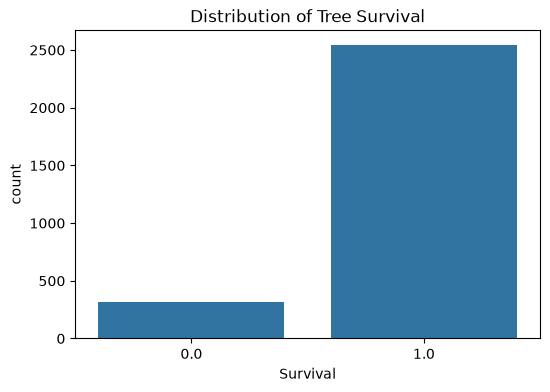

In [ ]:
# Survival Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survival',
    data=df
)

plt.title("Distribution of Tree Survival")
plt.show()

### **Insights**

#### Observation
The distribution of the target variable shows that the majority of trees survived (`Survival = 1`), while a much smaller proportion did not survive (`Survival = 0`). Approximately 2,500+ trees survived, compared to roughly 300–350 trees that did not survive.

#### Interpretation
This indicates that tree planting and management interventions within the surveyed sites were generally successful. The relatively high survival rate suggests that factors such as species selection, planting practices, watering, and maintenance may have positively contributed to seedling establishment.

The high survival rate demonstrates the effectiveness of restoration efforts under the Green Legacy Initiative. However, understanding the characteristics of the smaller group of non-surviving trees is crucial for identifying risk factors and improving future planting outcomes.

The predominance of surviving trees is encouraging from a restoration perspective because it demonstrates the potential effectiveness of large-scale tree planting programs. Nevertheless, the primary value of this study lies in identifying the conditions under which trees fail to survive, as reducing mortality can significantly improve restoration success and reduce replanting costs.


### **Top Tree Species**

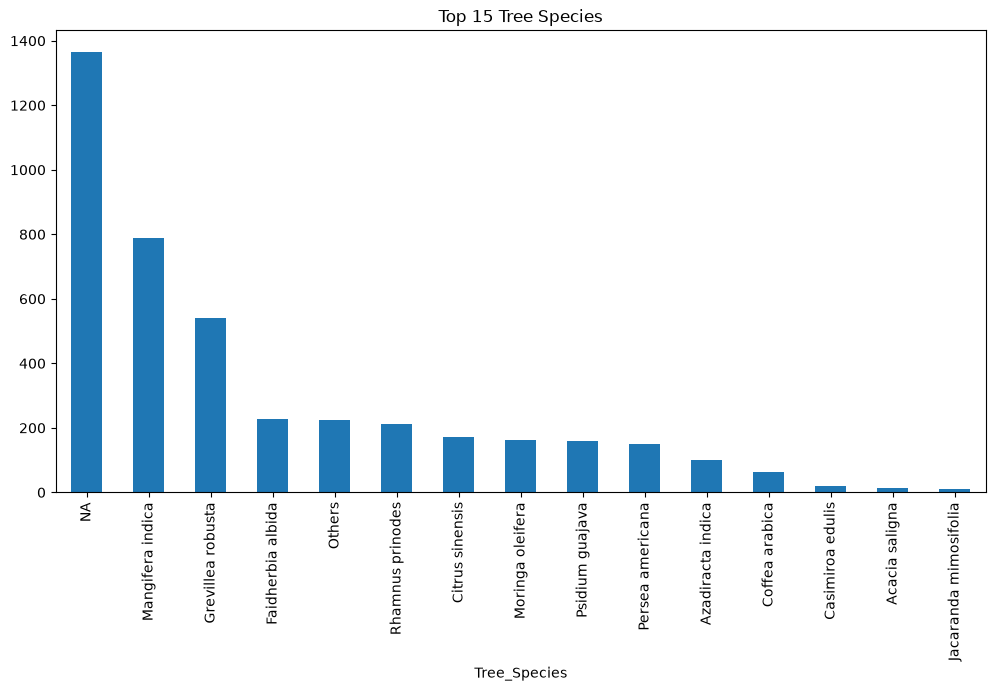

In [ ]:
# Tree Species Distribution - Dominant Species - 15 
plt.figure(figsize=(12,6))

df['Tree_Species'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Top 15 Tree Species")
plt.show()

### **Insights**

#### Observation

The dataset is dominated by a few tree species. The category "NA" has the highest frequency (approximately 1,360 records), followed by Mangifera indica (Mango) with about 790 records and Grevillea robusta with about 540 records. Other commonly planted species include Faidherbia albida, Rhamnus prinodes, Citrus sinensis, Moringa oleifera, and Psidium guajava.

### Interpretation
The results indicate that restoration and agroforestry programs in Ethiopia focus heavily on a few economically and environmentally important species.
    - Mangifera indica (Mango) is widely planted due to its food and income generation potential.
    - Grevillea robusta is a popular agroforestry species because of its fast growth, timber value, and compatibility with farming systems.
    - Fruit species such as mango, guava, citrus, and avocado suggest strong integration of livelihood and food security objectives within restoration programs.

The relatively lower occurrence of species such as Acacia saligna, Casimiroa edulis, and Jacaranda mimosifolia indicates that they are planted in specific locations or for specialized purposes. The distribution reveals a high concentration of planting efforts around a small number of species, which may influence overall survival outcomes. This finding suggests that:
    - Species selection plays a significant role in restoration projects.
    - The predictive model is likely to identify tree species as an important predictor of survival.
    - Some species may exhibit better survival rates than others under similar environmental and management conditions.

The dominance of economically valuable species suggests that restoration efforts are designed not only for environmental conservation but also for improving household livelihoods through fruit production, timber generation, and agroforestry benefits.

### **Data Cleaning - NA Missing Values**

In [62]:
# Replace "NA" with Actual Missing Values
df = df.replace(
    ['NA', 'N/A', 'na', 'null', 'NULL', ''],
    np.nan
)

In [63]:
# Re-evaluate Missing Values
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )
})

missing_values.sort_values(
    'Missing Values',
    ascending=False
).head(20)

,Missing Values,Percentage
Other_Reason2,4224,100.00
Other_Niche,4224,100.00
Other_Fert,4224,100.00
Other_Disease_Control,4224,100.00
Disease_Control_Meth,4224,100.00
Other_Reason1,4224,100.00
Other_Reason3,4224,100.00
Other_Regime,4223,99.98
Disease_Type,4176,98.86
Disease_Control,4176,98.86


#### **Insight**
Some columns actually contained missing data

#### **Visualize the missing values**

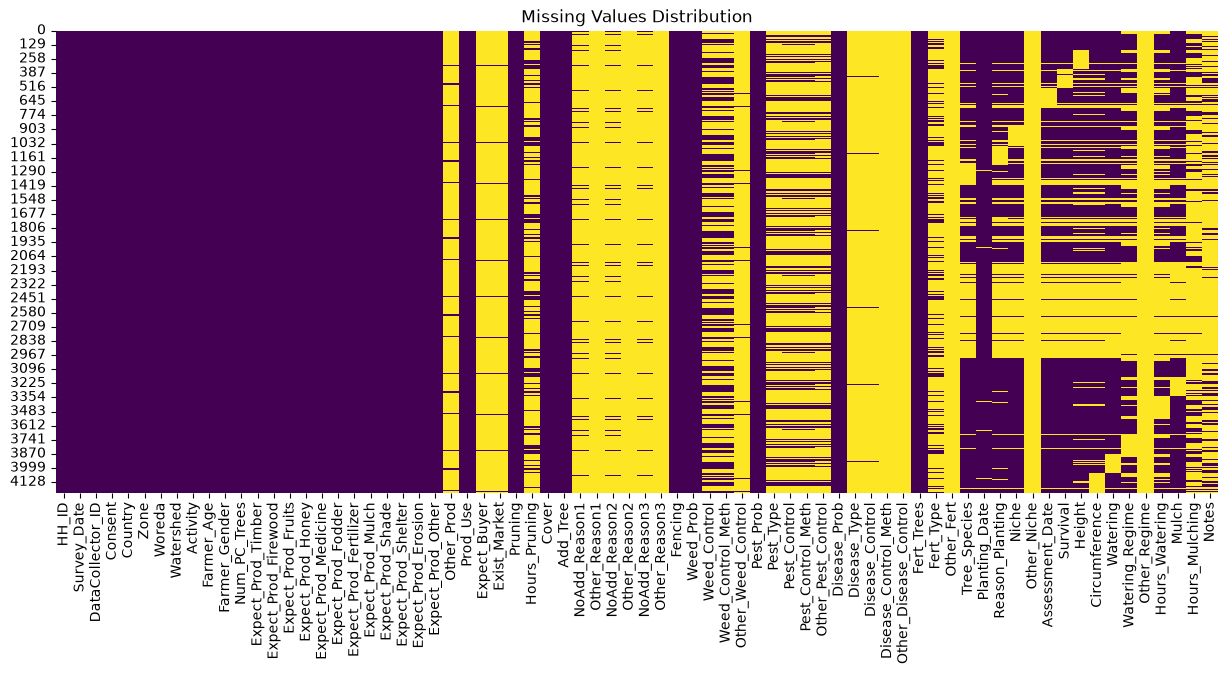

In [64]:
plt.figure(figsize=(15,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Distribution')
plt.show()

#### **Insight - Missing Values Distribution Heatmap**

The heatmap shows that missing values are not uniformly distributed across the dataset. Several variables are nearly complete, including:
    - HH\_ID
    - Survey\_Date
    - Country
    - Zone
    - Woreda
    - Farmer\_Age
    - Farmer\_Gender
    - Num\_PC\_Trees
These columns appear almost entirely populated. However, substantial missingness is observed in several variables, particularly:
    - Other\_Prod
    - Expect\_Buyer
    - Exist\_Market
    - NoAdd\_Reason1
    - NoAdd\_Reason2
    - NoAdd\_Reason3
    - Other\_Reason1
    - Other\_Reason2
    - Other\_Reason3
    - Weed\_Control\_Method
    - Pest\_Type
    - Disease\_Type
    - Other\_Disease\_Control
    - Other\_Fert
    - Other\_Niche
    - Other\_Regime
    - Notes
Some variables contain large blocks of missing values, indicating that they were only recorded under specific conditions and/or in conditional fields. For example:
    - A farmer can only have a value in `Pest_Type` if a pest problem was reported.
    - `Disease_Type` will only be recorded when disease is present.
    - `Other_Fert` is only applicable when "Other" fertilizer type is selected.
    - `NoAdd_Reason` fields are only applicable when additional trees were not planted.

Therefore, much of the missing data is likely structural or conditional missingness, rather than poor-quality data collection. The visualization demonstrates that the dataset contains a mixture of:
    1. Core variables with high completeness
    2. Conditional variables with naturally occurring missing values

In [ ]:
#Quantify the level of  missing values and identify which fetures may need to be dropped later
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': round(df.isnull().mean() * 100, 2)
})

missing_summary = missing_summary.sort_values(
    'Missing %',
    ascending=False
)

missing_summary.head(20)

,Missing Values,Missing %
Other_Reason2,4224,100.00
Other_Niche,4224,100.00
Other_Fert,4224,100.00
Other_Disease_Control,4224,100.00
Disease_Control_Meth,4224,100.00
Other_Reason1,4224,100.00
Other_Reason3,4224,100.00
Other_Regime,4223,99.98
Disease_Type,4176,98.86
Disease_Control,4176,98.86


#### ** Recheck Species Distribution**

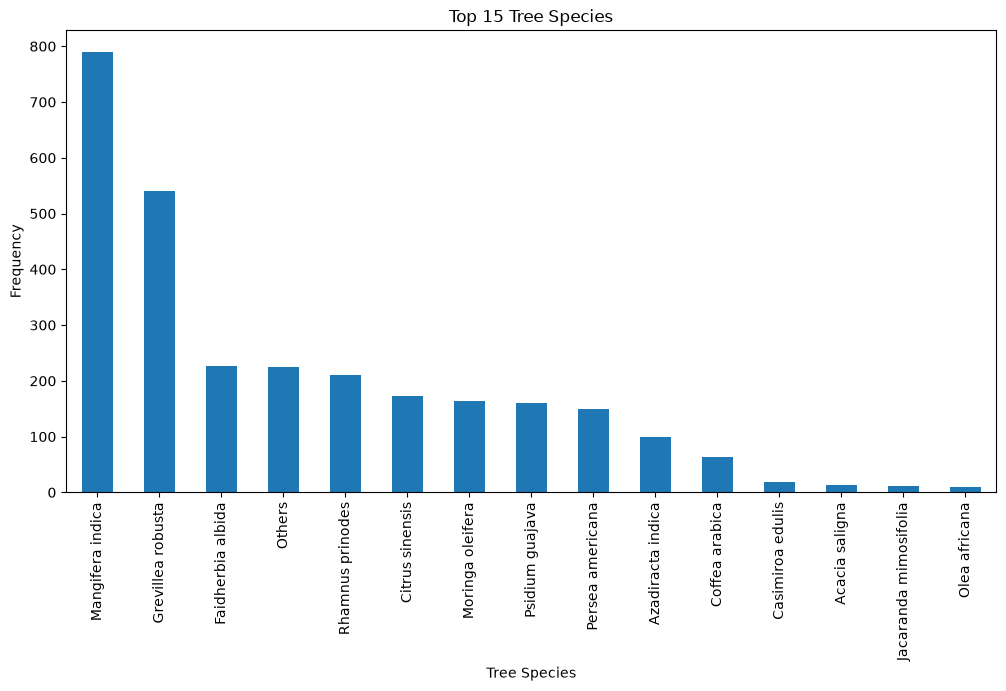

In [65]:
plt.figure(figsize=(12,6))

df['Tree_Species'].value_counts().head(15).plot(
    kind='bar'
)

plt.title('Top 15 Tree Species')
plt.xlabel('Tree Species')
plt.ylabel('Frequency')
plt.show()

#### **Insight after Data Cleaning**
During data quality assessment, several variables contained the value "NA" as a text string rather than a true missing value. These entries were converted to null values (NaN) to facilitate accurate statistical analysis, visualization, and machine learning preprocessing. This step improved data integrity and ensured that missing values could be handled systematically during subsequent stages of the CRISP-DM process.

### **Farmer Age Distribution**

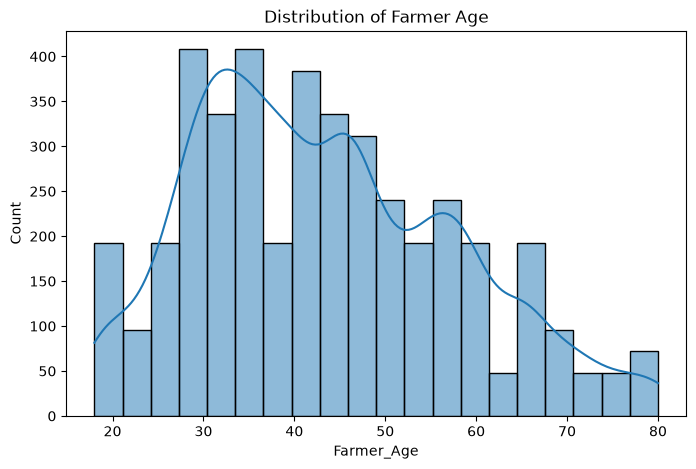

In [83]:
# Farmer Age Distribution - Showing age patterns
plt.figure(figsize=(8,5))

sns.histplot(
    df['Farmer_Age'],
    bins=20,
    kde=True
)

plt.title("Distribution of Farmer Age")
plt.show()

In [84]:
df['Farmer_Age'].describe()

count    4224.000000
mean       43.386364
std        14.340878
min        18.000000
25%        32.000000
50%        40.500000
75%        54.000000
max        80.000000
Name: Farmer_Age, dtype: float64

### **Insight - Farmer's Age**

**Descriptive Statistics**
    - Number of Farmers: 4,224
    - Mean Age: 43.39 years
    - Median Age: 40.50 years
    - Youngest Farmer: 18 years
    - Oldest Farmer: 80 years
    - Standard Deviation: 14.34 years

Farmer ages range from 18 to 80 years, with an average age of approximately 43 years. Half of the farmers are younger than 40.5 years and half are older. The majority of farmers fall between 32 and 54 years, as indicated by the interquartile range (IQR).

The age distribution indicates strong participation from middle-aged farmers, who represent the core productive workforce involved in tree planting and management activities. The relatively broad age range demonstrates that tree planting is practiced across multiple generations, although participation declines at older ages. The fact that the mean age (43.39) is slightly higher than the median age (40.5) suggests a mild right skew, driven by a smaller number of older farmers in the dataset. The active involvement of farmers in their productive years may positively influence tree survival through:
    - Better management practices
    - Greater labor availability
    - Increased experience in agroforestry and farming activities
    - Improved decision-making on watering, pest management, and maintenance

### **Height Patterns**

Text(0.5, 1.0, 'Tree Height Distribution')

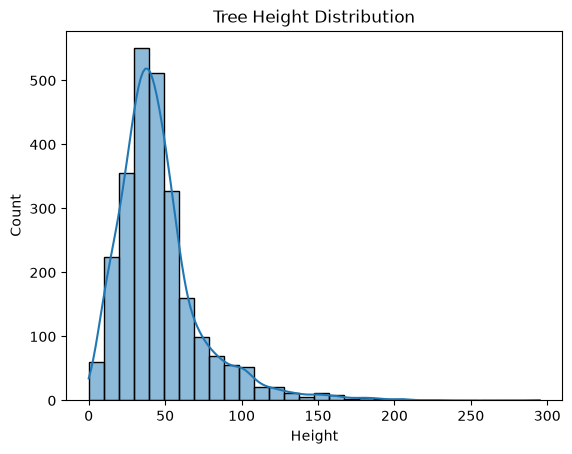

In [68]:
# Tree Height Distribution
sns.histplot(df['Height'], bins=30, kde=True)
plt.title('Tree Height Distribution')


In [86]:
df['Height'].describe()

count    2558.000000
mean       45.974605
std        28.318507
min         0.000000
25%        29.275000
50%        40.000000
75%        55.000000
max       295.000000
Name: Height, dtype: float64

In [ ]:
# Tree Species with exceptional growth
df.nlargest(10, 'Height')[[
    'Tree_Species',
    'Height',
    'Survival',
    'Zone',
    'Watering'
]]

,Tree_Species,Height,Survival,Zone,Watering
3657,Others,295.0,1.0,East Tigray,1
625,Citrus sinensis,224.5,1.0,Southeastern,1
3267,Grevillea robusta,206.0,1.0,Southeastern,1
3811,Grevillea robusta,205.0,1.0,Southeastern,1
1682,Grevillea robusta,203.5,1.0,Southeastern,1
4145,Grevillea robusta,190.5,1.0,Southeastern,1
1330,NaN,189.5,1.0,Southeastern,1
1681,Grevillea robusta,189.0,1.0,Southeastern,1
2035,Grevillea robusta,183.3,1.0,Southeastern,1
3975,Grevillea robusta,182.5,1.0,Southeastern,NaN


#### **Insights - Tree Height Distribution**

The tallest tree in the dataset reached 295 cm and belonged to the "Others"** species category in East Tigray. Most of the remaining tallest trees belong to Grevillea robusta, with heights ranging between 182.5 cm and 206 cm. Some of the notable patterns emerging are:
    - 7 of the top 10 tallest trees are Grevillea robusta.
    - Most of these high-performing trees are located in the Southeastern Zone.
    - All top-height trees recorded a Survival value of 1 (survived).
    - Most of these trees were also associated with watering practices.
    - Geographic location (Zone) is potentially an important factor affecting tree performance.

The dominance of Grevillea robusta among the tallest trees suggests that it is a highly adaptable and fast-growing species within the study area. Its repeated appearance among the best-performing trees indicates strong growth potential under local environmental and management conditions. The concentration of exceptionally tall trees in the Southeastern Zone may indicate that the region offers favorable growing conditions such as:
    - Better rainfall availability
    - More suitable soils
    - Superior management practices
    - Favorable climatic conditions
The fact that every tree among the top performers survived reinforces the relationship between vigorous growth and survival success.

In [88]:
df.columns

Index(['HH_ID', 'Survey_Date', 'DataCollector_ID', 'Consent', 'Country',
       'Zone', 'Woreda', 'Watershed', 'Activity', 'Farmer_Age',
       'Farmer_Gender', 'Num_PC_Trees', 'Expect_Prod_Timber',
       'Expect_Prod_Firewood', 'Expect_Prod_Fruits', 'Expect_Prod_Honey',
       'Expect_Prod_Medicine', 'Expect_Prod_Fodder', 'Expect_Prod_Fertilizer',
       'Expect_Prod_Mulch', 'Expect_Prod_Shade', 'Expect_Prod_Shelter',
       'Expect_Prod_Erosion', 'Expect_Prod_Other', 'Other_Prod', 'Prod_Use',
       'Expect_Buyer', 'Exist_Market', 'Pruning', 'Hours_Pruning', 'Cover',
       'Add_Tree', 'NoAdd_Reason1', 'Other_Reason1', 'NoAdd_Reason2',
       'Other_Reason2', 'NoAdd_Reason3', 'Other_Reason3', 'Fencing',
       'Weed_Prob', 'Weed_Control', 'Weed_Control_Meth', 'Other_Weed_Control',
       'Pest_Prob', 'Pest_Type', 'Pest_Control', 'Pest_Control_Meth',
       'Other_Pest_Control', 'Disease_Prob', 'Disease_Type', 'Disease_Control',
       'Disease_Control_Meth', 'Other_Disease_Control',

### **Circumference Distribution**

<Axes: xlabel='Circumference', ylabel='Count'>

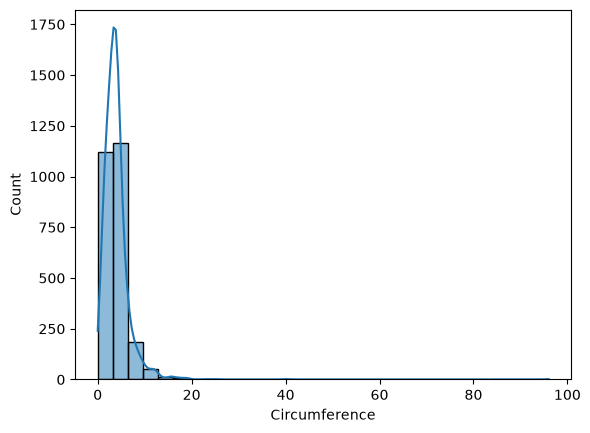

In [89]:
# Shows tree growth patterns.
sns.histplot(df['Circumference'], bins=30, kde=True)

### **Insights - Circumfrence Distribution**

The circumference distribution is highly right-skewed. From the histogram:
    - Most trees have relatively small circumferences, concentrated between approximately 2 and 8 units.
    - The distribution peaks around 4–6 units.
    - Only a few trees exhibit very large circumferences.
    - There are extreme values extending close to 100 units, creating a long right tail.

This indicates that while most seedlings are still in early growth stages, a small number have achieved substantially greater stem development. The skewed distribution suggests significant variation in tree growth performance across species, locations, and management practices. Possible explanations include:
    - Different planting ages
    - Differences in species growth rates
    - Variations in watering and maintenance
    - Site-specific environmental conditions
    - Pest and disease effects
Trees with larger circumferences are likely older, healthier, or growing under more favorable conditions.

Circumference appears to be a strong indicator of tree health and development. Just like height, circumference captures how successfully a seedling is establishing itself within its environment. The presence of a long right tail suggests that while most trees exhibit moderate growth, a subset of trees performs exceptionally well. These high-performing trees may provide valuable insights into:
    - Suitable species
    - Favorable growing environments
    - Effective management practices

Consequently, Circumference is likely to emerge as one of the most influential predictors in the survival prediction model.

## **Bivariate Analysis - Relationship Between Two Variables**

### **Survival vs Height**

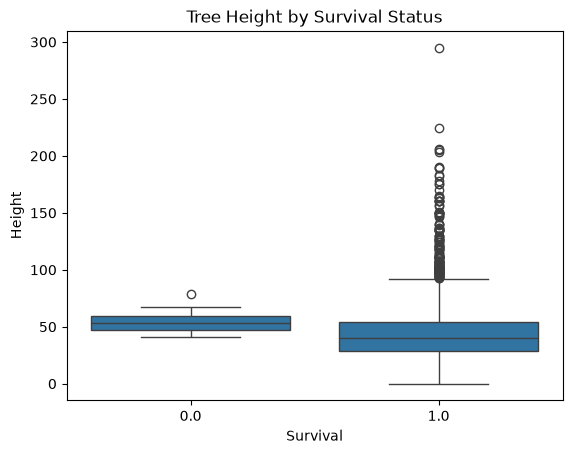

In [92]:
sns.boxplot(
    x='Survival',
    y='Height',
    data=df
)

plt.title('Tree Height by Survival Status')
plt.show()

### **Insight - Tree Height by Survival Status

The boxplot reveals a clear difference between surviving and non-surviving trees.

**Non-Surviving Trees (Survival = 0)**
    - Heights are concentrated around 45–60 cm.
    - The distribution is relatively narrow.
    - There are very few extreme values.
    - The median height appears to be around 50 cm.

**Surviving Trees (Survival = 1)**
    - Heights show much greater variability.
    - The median height is slightly lower than that of non-surviving trees.
    - There are numerous high-value outliers.
    - Several trees exceed 100 cm*, with some reaching nearly 300 cm.

At first glance, it may seem surprising that surviving trees have a lower median height than non-surviving trees. However, the plot also shows that surviving trees include:
    - Very young seedlings
    - Recently planted trees
    - Moderate-growth trees
    - Exceptionally tall trees
This creates a wider spread of values. The large number of outliers among surviving trees suggests that many of the best-performing trees belong exclusively to the survival group, which is expected because trees must survive in order to continue growing and reach large heights.

The key takeaway is not the median difference but the growth potential. Only surviving trees achieve exceptional heights. The tallest trees in the dataset:
    - All survived
    - Reached heights between 180 cm and 295 cm
    - Were largely represented by Grevillea robusta

This strongly suggests that survival is a prerequisite for achieving substantial growth. Height therefore captures more than size, it reflects:
    - Tree vigor
    - Site suitability
    - Management effectiveness
    - Species adaptability

Trees that continue to survive gain opportunities for:
    - Increased biomass accumulation
    - Carbon sequestration
    - Timber production
    - Ecological restoration benefits

Poor-performing trees, regardless of their initial height, may not attain these long-term benefits. Consequently, height measurements can serve as an early indicator of plantation performance and restoration success.

### **Survival vs Tree Species**

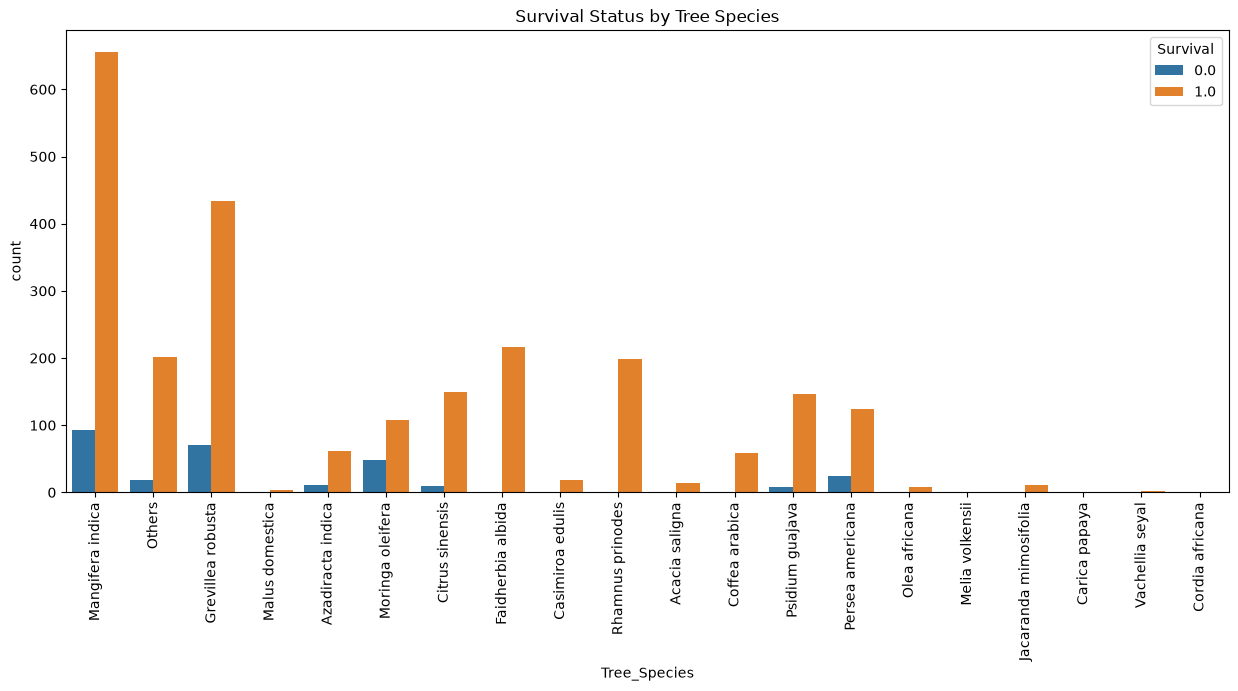

In [97]:
#Which species survive best?
plt.figure(figsize=(15,6))

sns.countplot(
    x='Tree_Species',
    hue='Survival',
    data=df
)

plt.xticks(rotation=90)


plt.title('Survival Status by Tree Species')
plt.show()



### **Insights - Tree Species vs Survival Status - Based on Count**

The chart shows substantial variation in survival counts across different tree species. The most frequently planted species include:
    - Mangifera indica (Mango)
    - Grevillea robusta
    - Faidherbia albida
    - Rhamnus prinodes
    - Citrus sinensis
    - Psidium guajava

Across nearly all species, the number of surviving trees is significantly greater than the number of non-surviving trees. Notable observations include:
    - Mangifera indica records the highest number of surviving trees.
    - Grevillea robusta also demonstrates a very high number of surviving trees.
    - Species such as Rhamnus prinodes, Faidherbia albida, and Citrus sinensis show strong survival performance with relatively few failures.
    - Some species exhibit very few observations, making it difficult to draw firm conclusions regarding their performance.

The variation in survival counts across species suggests that species selection is an important determinant of restoration success. Species such as Mangifera indica and Grevillea robusta appear to perform particularly well within the study areas. These species may possess characteristics that make them better adapted to local environmental conditions, management practices, or climatic conditions. However, it is important to note that species with larger survival counts may also have been planted more frequently. Therefore, absolute counts should be interpreted alongside planting frequency. Species exhibiting lower survival rates may require:
    - Better management
    - Improved site selection
    - Additional research into establishment challenges

### **Follow-up Analysis**

In [93]:
## Survival rate by species
species_survival_rate = pd.crosstab(
    df['Tree_Species'],
    df['Survival'],
    normalize='index'
) * 100

species_survival_rate

Survival,0.0,1.0
Tree_Species,,
Acacia saligna,0.000000,100.000000
Azadiracta indica,15.277778,84.722222
Carica papaya,0.000000,100.000000
Casimiroa edulis,0.000000,100.000000
Citrus sinensis,6.250000,93.750000
Coffea arabica,0.000000,100.000000
Cordia africana,0.000000,100.000000
Faidherbia albida,0.000000,100.000000
Grevillea robusta,13.888889,86.111111


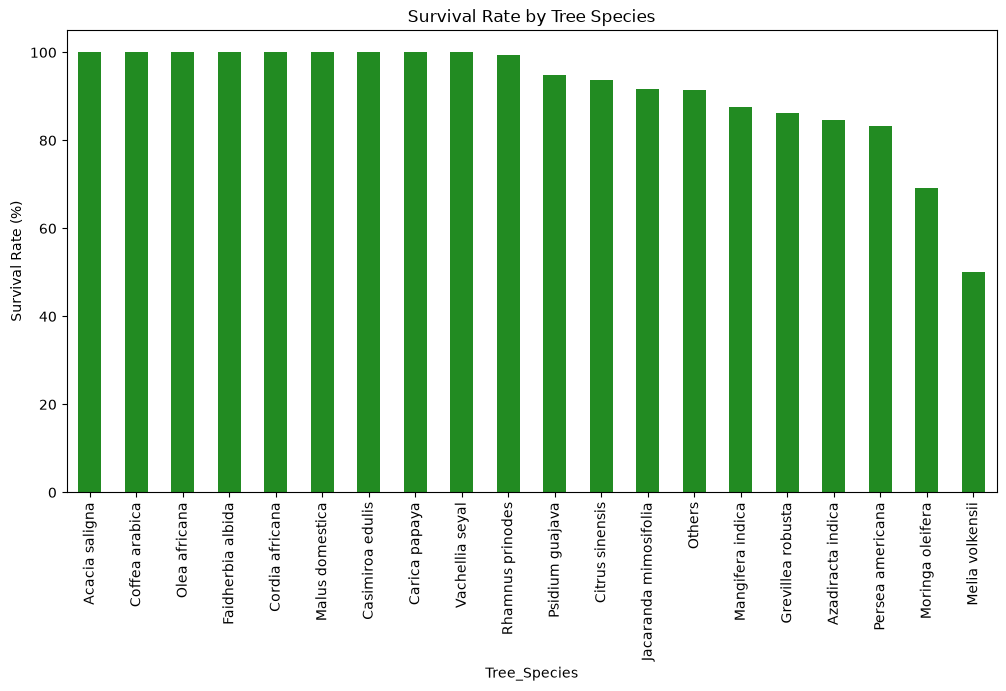

In [94]:
species_survival_rate[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,6),
    color='forestgreen'
)

plt.title('Survival Rate by Tree Species')
plt.ylabel('Survival Rate (%)')
plt.show()

### **Insights - Survival Rate by Tree Species**

This visualization normalizes survival by species and removes the bias caused by different planting frequencies. The chart reveals substantial variation in survival rates among tree species.

**Species with Near-Perfect Survival (≈100%)**
    - Acacia saligna
    - Coffea arabica
    - Olea africana
    - Faidherbia albida
    - Cordia africana
    - Malus domestica
    - Casimiroa edulis
    - Carica papaya
    - Vachellia seyal
These species recorded survival rates close to 100%.

**Species with Strong Survival Rates (90–99%)**
    - Rhamnus prinodes
    - Psidium guajava
    - Citrus sinensis
    - Jacaranda mimosifolia
These species also performed exceptionally well.

**Moderate Survival Rates (80–90%)**
    - Mangifera indica
    - Grevillea robusta
    - Azadiracta indica
    - Persea americana
Although these species have slightly lower percentages, they still demonstrate strong survival performance.

**Lowest Survival Rates**
    - Moringa oleifera (\~69%)
    - Melia volkensii (\~50%)
These species exhibited noticeably lower survival rates compared to the rest.

The results clearly demonstrate that survival is not uniform across species. Some species appear exceptionally adapted to local environmental conditions, while others experience greater establishment challenges. The near-perfect performance of species such as:
    - Faidherbia albida
    - Coffea arabica
    - Olea africana
    - Cordia africana
Suggests strong ecological suitability within the study areas. Conversely, the lower survival rates observed for Melia volkensii and Moringa oleifera may indicate:
    - Species-site mismatches
    - Higher sensitivity to environmental stress
    - Greater management requirements
    - Smaller sample sizes

This demonstrate excellent survival potential and may be prioritized in suitable ecological zones. Species with lower survival rates may require:
    - Improved maintenance
    - Site-specific planting recommendations
    - Additional research before large-scale deployment

Tree species is one of the strongest determinants of tree survival, with survival rates varying from approximately 50% to nearly 100% across different species.

### **Survival vs Watering**

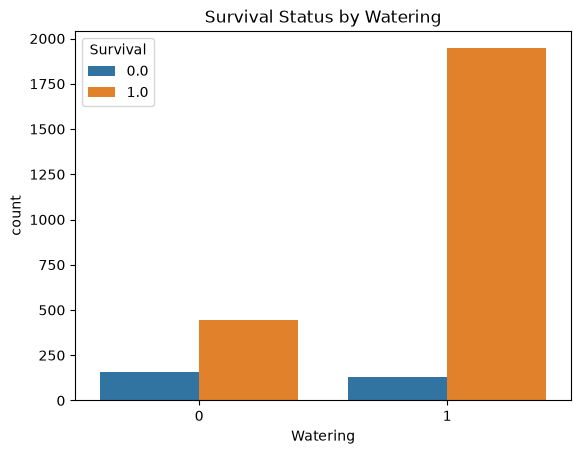

In [96]:
# Does watering improve survival?
sns.countplot(
    x='Watering',
    hue='Survival',
    data=df
)

plt.title('Survival Status by Watering')
plt.show()

### **Insights - Survival Status by Watering**

This visualization links a management practice directly to survival outcomes. The chart reveals a clear difference between watered and non-watered trees.

**Trees Without Watering (`Watering = 0`)**
    - Surviving trees: approximately 450
    - Non-surviving trees: approximately 150

**Trees With Watering (`Watering = 1`)**
    - Surviving trees: approximately 1,950
    - Non-surviving trees: approximately 130

The number of surviving trees among watered seedlings is substantially higher than among non-watered seedlings. The results suggest a strong positive association between watering and tree survival. Although some trees survived without watering, survival was much more common among trees that received watering support. Similarly, the proportion of non-surviving trees appears relatively lower within the watered group. This is expected because water is one of the most critical factors affecting:
    - Seedling establishment
    - Root development
    - Nutrient uptake
    - Resistance to drought stress

This visualization provides strong evidence that watering is a major determinant of survival success. Unlike species, which cannot easily be changed once selected, watering represents a management intervention that forestry practitioners can directly control. This means that improving watering practices could have an immediate impact on restoration success.


### **Survival vs Fertilizer**

In [72]:
# Impact of fertilizer

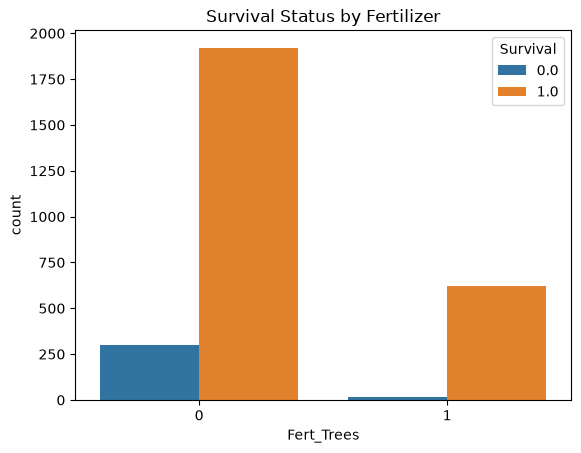

In [99]:
sns.countplot(
    x='Fert_Trees',
    hue='Survival',
    data=df
)
plt.title('Survival Status by Fertilizer')
plt.show()

### **Insights - Survival Status by Fertilizer Application**

This visualization evaluates whether fertilizer application influences tree survival. The chart compares survival outcomes between trees that received fertilizer (`Fert_Trees = 1`) and those that did not (`Fert_Trees = 0`).

**Trees Without Fertilizer**
    - Approximately 1,900+ trees survived
    - Approximately 300 trees did not survive

**Trees With Fertilizer**
    - Approximately 620 trees survived
    - Only a very small number of trees failed to survive
A striking observation is that the fertilizer group has very few failures relative to the number of surviving trees. At first glance, fertilizer-treated trees appear to exhibit better survival outcomes than untreated trees. However, the chart presents counts rather than survival rates, meaning we must interpret cautiously because:
    - Far more trees were planted without fertilizer.
    - The two groups have different sample sizes.
    - Higher survival counts in one group may simply reflect a larger number of observations.
Nevertheless, the noticeably low number of failures in the fertilized group suggests a potentially positive relationship between fertilizer application and seedling survival.

Fertilizer application appears to contribute positively to tree establishment and growth. Fertilizers improve:
    - Nutrient availability
    - Root development
    - Early seedling vigor
    - Resistance to environmental stress
Consequently, trees receiving fertilizer may be better equipped to survive adverse environmental conditions.

### **Height vs Survival**

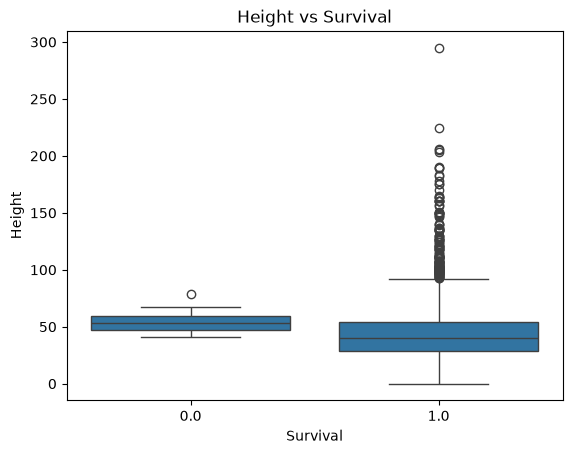

In [100]:
# Height vs Survival
sns.boxplot(
    x='Survival',
    y='Height',
    data=df
)
plt.title('Height vs Survival')
plt.show()

### **Insights - Height vs Survival**

This bivariate analysis directly evaluates the relationship between a key growth indicator -Height and the target variable- Survival.

The boxplot reveals a noticeable difference in height distributions between surviving and non-surviving trees.

**Non-Surviving Trees (Survival = 0)**
    - Heights are concentrated within a relatively narrow range.
    - The median height is approximately 50 cm.
    - Few outliers are observed.
    - Maximum height is below 80 cm.

**Surviving Trees (Survival = 1)**
    - Heights show substantially greater variation.
    - Numerous extreme outliers are present.
    - Several surviving trees exceed 100 cm in height.
    - The tallest surviving tree approaches 300 cm.

The survival group contains:
    - Newly planted seedlings
    - Young trees
    - Mature trees
    - Exceptionally high-growth trees
This broad mixture creates greater variability and lowers the median value. The critical finding is that all exceptionally tall trees belong to the survival group. Trees cannot achieve substantial heights unless they survive long enough to continue growing. Height appears to be strongly related to long-term survival and growth performance.

The visualization suggests that:
    - Survival enables continued growth.
    - High-performing trees are exclusively found among surviving trees.
    - Height captures important information about tree vigor, adaptation, and management success.

The large number of high-growth outliers among surviving trees indicates that some trees benefited from particularly favorable combinations of:
    - Species selection
    - Water availability
    - Site conditions
    - Management practices

Monitoring height growth can help identify successful restoration interventions and detect struggling seedlings before mortality occurs.


### **Circumfrence vs Survival**

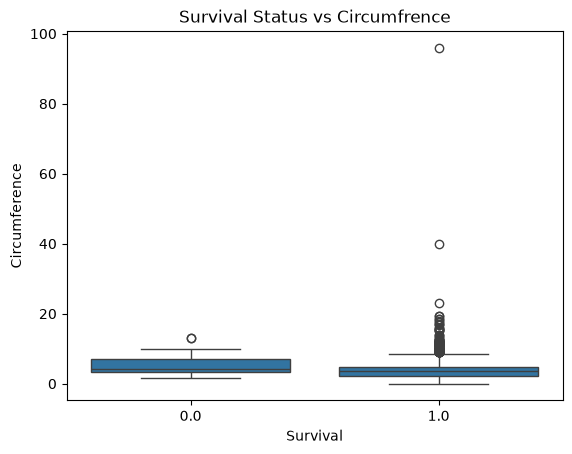

In [101]:
sns.boxplot(
    x='Survival',
    y='Circumference',
    data=df
)
plt.title('Survival Status vs Circumfrence')
plt.show()

### **Insights - Survival Status vs Circumference**

This visualization complements the Height analysis by examining whether stem development (circumference) is associated with survival outcomes. 
The boxplot reveals noticeable differences between surviving and non-surviving trees.

**Non-Surviving Trees (Survival = 0)**
    - Circumference values are concentrated between approximately 2 and 7 units.
    - Limited variation is observed.
    - Very few extreme values are present.
    - Maximum circumference is approximately 13 units.

**Surviving Trees (Survival = 1)**
    - Circumference values exhibit much greater variability.
    - Numerous outliers are present.
    - Some surviving trees exceed 20 units.
    - The largest observed circumference approaches 100 units.

Most importantly: All extremely large circumference values belong to surviving trees.

Although the median circumference appears slightly lower among surviving trees, this pattern is similar to what was observed for height. The survival category contains:
    - Newly planted seedlings
    - Young trees
    - Mature trees
    - Exceptional performers
This broad range increases variability and lowers the median. However, the key finding is that trees with exceptionally large stem development are found exclusively within the survival class.

Circumference appears to be a strong indicator of:
    - Tree vigor
    - Structural development
    - Resource availability
    - Long-term establishment success
    - Stronger root systems
    - Better nutrient uptake
    - Increased drought resilience
    - Greater biomass accumulation

Just as trees must survive to grow tall, they must also survive to develop large stem circumferences. The concentration of large circumference values within the survival group suggests that successful establishment enables continued biomass accumulation and structural growth. This makes Circumference a potentially important predictor in the machine learning models.

In [ ]:
### **Farmer's Age vs Survival**

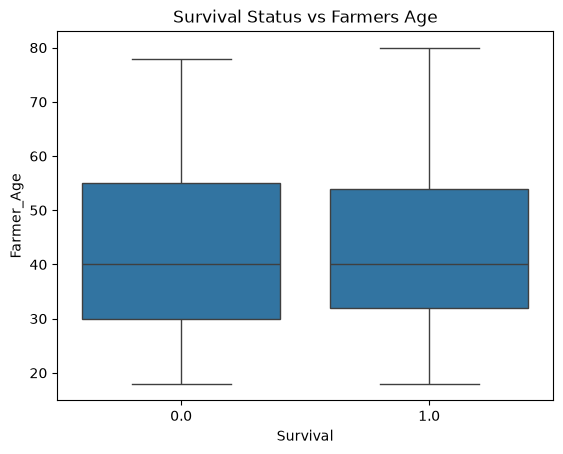

In [112]:
sns.boxplot(
    x='Survival',
    y='Farmer_Age',
    data=df
)
plt.title('Survival Status vs Farmers Age')
plt.show()


### **Insights - Survival Status vs Farmer Age**

This is a very interesting result because, unlike watering, species, height, or circumference, Farmer Age does not appear to have a strong relationship with tree survival. The boxplots for both survival groups (`0 = Not Survived`, `1 = Survived`) are remarkably similar. Key observations include:
    - Both groups have a median age of approximately 40 years.
    - The interquartile ranges (middle 50% of observations) are almost identical.
    - Both groups span a similar age range from approximately 18 to 80 years.
    - There are no obvious outliers or large differences between the distributions.

Unlike variables such as watering and species, farmer age alone does not appear to distinguish between surviving and non-surviving trees. This suggests that:
    - Younger and older farmers achieved similar survival outcomes.
    - Tree survival may depend more on management practices, species choice, environmental conditions, and site factors than on farmer age itself.

The similarity of the distributions indicates that age is unlikely to be a primary driver of seedling survival. While age may reflect farming experience and decision-making capacity, the results suggest that these advantages do not automatically translate into higher tree survival.

### Species vs Zone

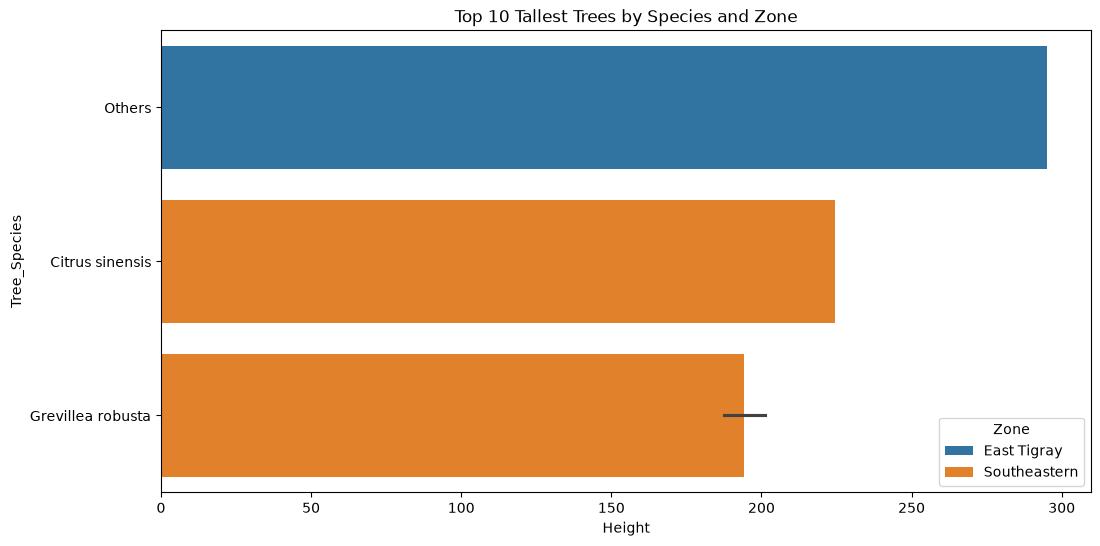

In [113]:
top10 = df.nlargest(10, 'Height')

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Height',
    y='Tree_Species',
    hue='Zone'
)

plt.title('Top 10 Tallest Trees by Species and Zone')

plt.show()


### **Insights - Top 10 Tallest Trees by Species and Zone**

This supporting visualization combines growth performance (Height), pecies characteristics, and geographic location (Zone) in a single chart. The chart reveals that the tallest trees in the dataset are concentrated among a few species and locations. Key observations include:
    - The tallest recorded tree reached approximately 295 cm and belongs to the "Others" category in East Tigray.
    - Citrus sinensis achieved the second-highest recorded height at approximately 225 cm in the Southeastern Zone.
    - Grevillea robusta dominates the top-performing trees, with several individuals exceeding 180 cm in height.
    - Most of the tallest trees are concentrated in the Southeastern Zone.
    - Only one of the top performers belongs to East Tigray.

The strong representation of Grevillea robusta among the tallest trees suggests that it possesses exceptional growth potential under suitable environmental and management conditions. The clustering of high-growth trees in the Southeastern Zone may indicate:
    - More favorable climatic conditions
    - Better soil characteristics
    - More effective management practices
    - Greater availability of water during establishment

The results suggest that both species selection and site conditions influence growth performance. This visualization demonstrates that outstanding tree growth is not random. Instead, exceptional growth appears to result from the interaction of:
    - Species Adaptability
    - Environmental Conditions
    - Management Practices

The repeated appearance of Grevillea robusta among the tallest trees reinforces its status as one of the best-performing species in the dataset. 
Similarly, the dominance of the Southeastern Zone suggests that geographic location may significantly influence restoration outcomes. The findings highlight the importance of species-to-site matching in restoration programs.

The strong performance of Grevillea robusta suggests it may be particularly suitable for environments similar to those found in the Southeastern Zone. Rather than adopting a uniform planting strategy, restoration initiatives should consider:
    - Which species perform best in specific ecological zones
    - Local climate conditions
    - Site suitability characteristics

This can improve survival, growth, and overall restoration success.

## **Multivariate Analysis**

### **Correlation Heatmap**

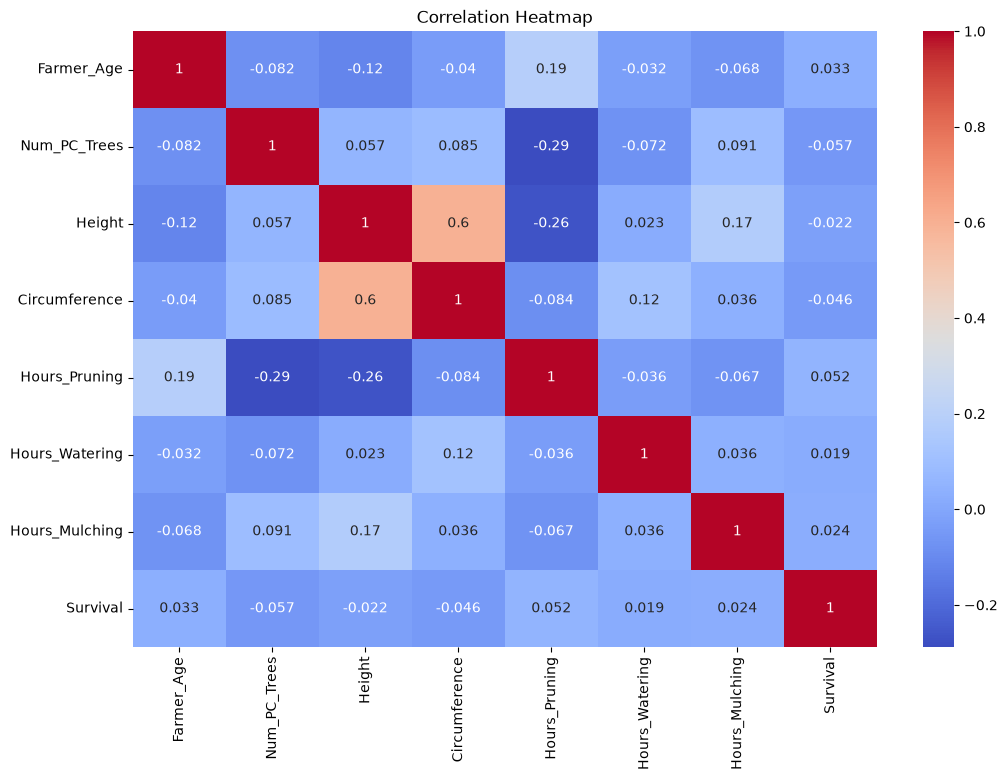

In [115]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')

plt.show()


### **Insights - Correlation Heatmap (Multivariate Analysis)**

This helps identify relationships among the numerical variables and potential multicollinearity issues. Most correlations in the dataset are weak, indicating that the variables capture different aspects of tree survival and growth. The most notable relationships include:

**Strong Positive Correlation**
    - Height vs Circumference - This is the strongest relationship in the dataset. Trees with greater heights tend to have larger stem circumferences.

**Moderate Negative Correlation**
    - Num\_PC\_Trees vs Hours\_Pruning - Households with more planted trees appear to spend slightly fewer pruning hours per tree.
    - Height vs Hours\_Pruning - Taller trees tend to require less pruning effort.

**Weak Positive Relationships**
    - Farmer\_Age vs Hours\_Pruning - Older farmers may spend slightly more time pruning.
    - Height vs Hours\_Mulching - Mulching may contribute to better growth performance.

**Survival Correlations**
    - The survival variable shows very weak linear correlations with all numerical variables.



At first glance, these weak correlations may seem surprising because earlier visualizations clearly showed that:
    - Watering influences survival.
    - Species influences survival.
    - Height and circumference differ between survival groups.

However, correlation only measures linear relationships between numerical variables. Several key predictors in the dataset are:
    - Tree Species
    - Watering (categorical/binary)
    - Fertilizer Application
    - Zone
    - Pest Occurrence

The weak correlations between survival and individual numerical variables suggest that:
    - Tree survival is influenced by a combination of factors rather than a single variable. The relationship is likely:
        - Non-linear
        - Interactive
        - Species-dependent
        - Management-dependent

### **Pairplot**

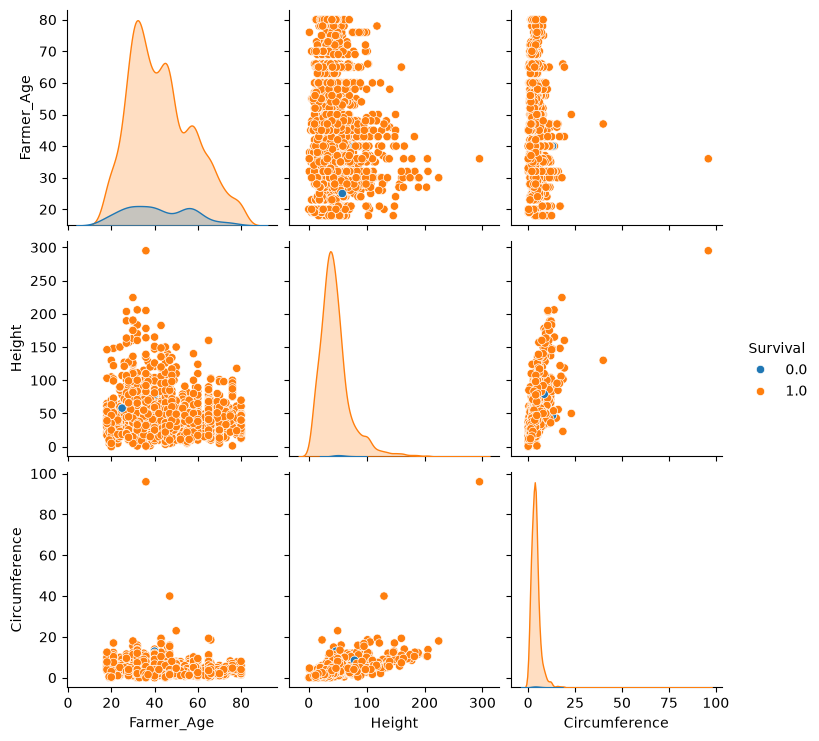

In [117]:
# Shows several relationships at once
sns.pairplot(
    df[
        [
            'Farmer_Age',
            'Height',
            'Circumference',
            'Survival'
        ]
    ],
    hue='Survival'
)



### **Insights - Pairplot Analysis (Farmer Age, Height, Circumference, Survival)**

The pairplot reveals several important patterns:

    -  Height and Circumference Show a Clear Positive Relationship. Among all variable pairs, the strongest visual relationship is between      Height and Circumference. As tree height increases, circumference also tends to increase. Trees that grow taller generally develop thicker stems.

    - Farmer Age Has Weak Relationships with Growth Variables. The scatterplots involving Farmer_Age & Height and Farmer_Age & Circumference show no obvious pattern. The points are widely dispersed, indicating that age alone does not strongly influence tree growth. This supports the findings from the boxplot analysis.

    - Surviving Trees Dominate the Dataset. The orange points (Survival = 1) significantly outnumber the blue points (Survival = 0). This confirms the class imbalance identified earlier.

    - Extreme Growth Observations Belong Almost Entirely to Surviving Trees. The tallest trees and largest stem circumferences are almost exclusively associated with Survival = 1. No comparable outliers exist for the non-survival group.


The pairplot reinforces several findings already observed throughout the EDA. Tree growth variables appear closely connected, while farmer age contributes relatively little explanatory power. The concentration of large heights and circumferences within the survival class suggests that successful establishment enables continued growth and biomass accumulation. This confirms that height and circumference are not merely measurements of size, they are indicators of restoration success.

The analysis reveals two major patterns:
    - Growth Metrics Move Together: Height and circumference increase together, indicating that they measure complementary dimensions of tree development.
    - Survival Is Associated with Growth Success: Trees that survive are the only ones capable of reaching exceptional growth levels.

This suggests that:
    - Height and circumference are likely to become important predictors.
    - Farmer age may have limited predictive contribution.
    - Survival is influenced more by biological and management factors than demographic factors.

### **Species + Watering + Survival**

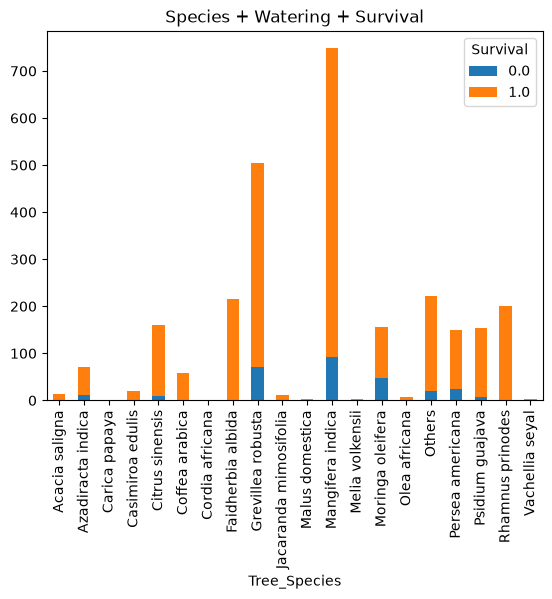

In [118]:
# Shows performance by species
pd.crosstab(
    df['Tree_Species'],
    df['Survival']
).plot(kind='bar', stacked=True)

plt.title('Species + Watering + Survival')

plt.show()

### **Insights - Tree Species and Survival Status (Stacked Count Analysis)**

This visualization shows the ctual number of surviving and non-surviving trees for each species, helping us understand both adoption/popularity and performance.

The chart reveals significant variation in the number of trees planted across species. The most frequently planted species include:
    - Mangifera indica (highest count)
    - Grevillea robusta
    - Others
    - Faidherbia albida
    - Rhamnus prinodes
    - Psidium guajava
    - Persea americana

Across almost all species, surviving trees greatly outnumber non-surviving trees. Notable observations include:
    - Mangifera indica has the highest number of surviving trees.
    - Grevillea robusta records the second-largest number of surviving trees.
    - Faidherbia albida shows strong survival with very few failures.
    - Melia volkensii exhibits a relatively high proportion of failures compared to its total count.
    - Several species show little or no mortality.

This chart tells us more about species adoption than species efficiency. For example:
    - Mangifera indica has many surviving trees largely because it was planted extensively.
    - Grevillea robusta also contributes significantly to the total restoration success because of its widespread use.
    - Species with fewer observations may show excellent survival rates but contribute fewer surviving trees overall.

This explains why both the count chart and the survival-rate chart are necessary:
    - Count chart shows contribution to restoration.
    - Survival-rate chart shows survival efficiency.

The results suggest that restoration success depends on both:
     - Quantity Planted: Species such as Mangifera indica and Grevillea robusta contribute most to overall restoration success because large numbers were planted and survived.
     - Survival Performance: Species such as Faidherbia albida, Coffea arabica and Cordia africana achieve exceptionally high survival rates.

A successful restoration strategy should therefore balance large-scale deployment of popular species and introduction of high-performing species with proven survival success.

### **Survival by Zone**

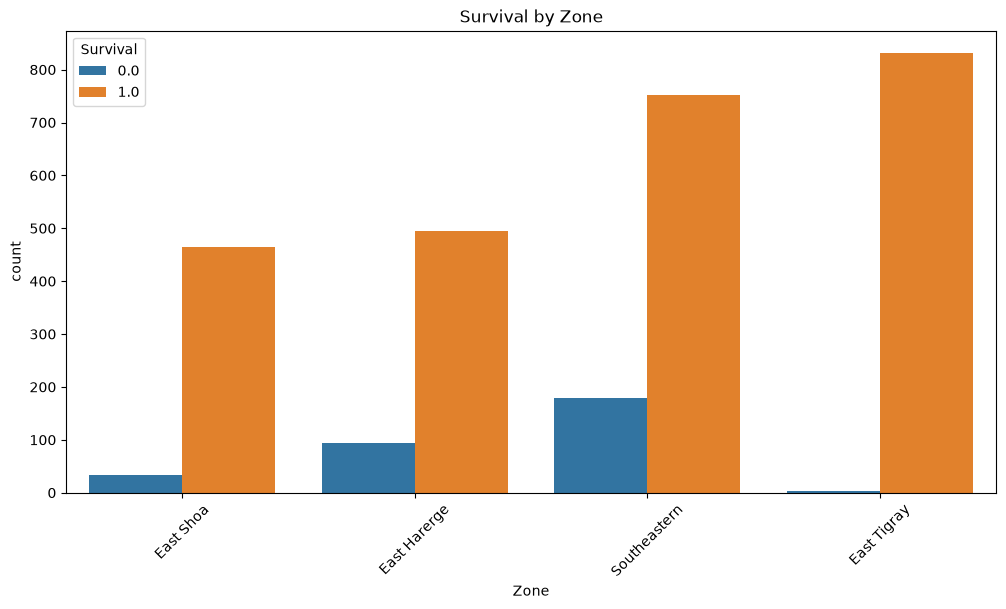

In [123]:
#Geographic Location - Ecozone concept
plt.figure(figsize=(12,6))

sns.countplot(
    x='Zone',
    hue='Survival',
    data=df
)

plt.xticks(rotation=45)

plt.title('Survival by Zone')

plt.show()

### **Insights - Survival by Zone**

This geographical analysis helps determine whether tree survival differs across ecological regions.


The chart shows clear differences in survival counts across the four zones:
    - East Tigray: Records the highest number of surviving trees and the lowest number of failures.
    - Southeastern: Has a large number of surviving trees but also the largest number of failures.
    - East Shoa: Demonstrates good survival performance with relatively few failures.
    - East Harerge: Performs moderately, with a slightly higher number of failures than East Shoa.

The differences observed across zones suggest that location plays an important role in tree survival outcomes. Several factors may explain these variations:
    - Rainfall patterns
    - Soil characteristics
    - Temperature conditions
    - Species composition
    - Management practices
    - Water availability

The exceptionally strong performance observed in East Tigray may indicate highly favorable environmental conditions or more effective tree management practices. The relatively high number of failures in the Southeastern zone may result from:
    - Larger planting volumes
    - Greater environmental variability
    - More challenging growing conditions

## **Added visualizations for better data understanding**

### **Missing values heatmap**

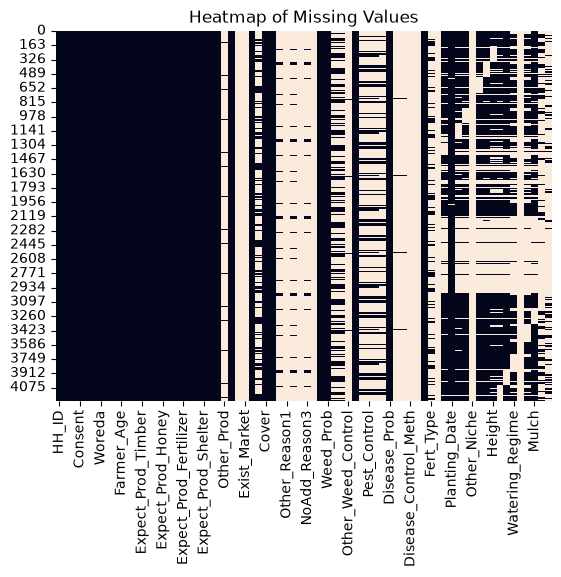

In [122]:
sns.heatmap(
    df.isnull(),
    cbar=False
)
plt.title('Heatmap of Missing Values')

plt.show()

### ****Insights - Heatmap of Missing Values**

This provides a visual map of data completeness across all variables. The heatmap clearly shows that missing values are not randomly distributed throughout the dataset.

Highly Complete Variables: Most of the core variables appear complete, including:
    - HH\_ID
    - Consent
    - Zone
    - Woreda
    - Farmer\_Age
    - Farmer\_Gender
    - Num\_PC\_Trees
    - Survival
These variables contain very few or no missing values.

Variables with Significant Missing Values: Large concentrations of missing values appear in:
    - Other\_Prod
    - Expect\_Buyer
    - Exist\_Market
    - NoAdd\_Reason1
    - NoAdd\_Reason2
    - NoAdd\_Reason3
    - Other\_Reason1
    - Other\_Reason2
    - Other\_Reason3
    - Weed\_Control\_Meth
    - Pest\_Type
    - Disease\_Type
    - Other\_Disease\_Control
    - Other\_Fert
    - Other\_Niche
    - Other\_Regime

The missing values appear as large vertical bands across these variables. The pattern suggests that most missing values are structural (conditional) rather than caused by poor data collection.

The heatmap reveals two categories of variables:

**Core Predictive Variables**
These are highly complete and suitable for modelling:
    - Tree\_Species
    - Survival
    - Height
    - Circumference
    - Watering
    - Farmer\_Age
    - Zone
    - Fert\_Trees

**Conditional Variables**
These contain substantial missingness and require special treatment:
    - Pest\_Type
    - Disease\_Type
    - Other\_Fert
    - Notes
    - Other\_Niche

The missing-value structure reflects the diversity of real-world restoration conditions. Not every farmer experienced pests, applied fertilizer, faced disease outbreaks and undertook selected alternative management practices. This suggests that restoration outcomes depend on highly variable local management conditions. The dataset therefore captures realistic complexity rather than systematic data quality problems.

## **Conclusion of the Exploratory Data Analysis (EDA)**

The Exploratory Data Analysis (EDA) provided valuable insights into the factors influencing tree survival in Ethiopia's restoration and agroforestry programs. The analysis revealed that overall tree survival rates were high, indicating generally successful restoration efforts and effective establishment of planted seedlings.

Species selection emerged as one of the most influential factors affecting survival. Significant variations were observed across tree species, with survival rates ranging from approximately 50% to almost 100%. Species such as Faidherbia albida, Coffea arabica, Cordia africana, and Olea africana demonstrated exceptional survival performance, while Melia volkensii and Moringa oleifera exhibited comparatively lower survival rates. In terms of overall contribution to restoration success, Mangifera indica and Grevillea robusta accounted for the highest numbers of surviving trees.

Management practices were also found to play a critical role in seedling survival. Watering emerged as the strongest management-related factor, increasing survival rates from approximately 74% among non-watered seedlings to about 94% among watered seedlings. Fertilizer application similarly showed a positive association with survival, suggesting that post-planting management interventions significantly enhance restoration outcomes.

Growth indicators, particularly tree height and circumference, were strongly associated with successful survival. Surviving trees exhibited substantially greater variation in both height and stem circumference and accounted for all exceptional growth observations. The tallest trees in the dataset reached heights approaching 300 cm, while the largest stem circumferences approached 100 units. Furthermore, a strong positive relationship was observed between height and circumference, indicating that vertical and radial growth occur simultaneously as trees establish successfully.

Geographical analysis revealed notable variation in survival outcomes across zones. East Tigray recorded the highest number of surviving trees and relatively few failures, while the Southeastern zone hosted many of the tallest trees in the dataset. These findings suggest that environmental conditions, ecological suitability, and local management practices influence restoration success.

Conversely, farmer age showed little relationship with survival outcomes. Both surviving and non-surviving trees were associated with farmers of similar age distributions, indicating that demographic characteristics play a less significant role than biological, environmental, and management factors.

The correlation and pairplot analyses further demonstrated that tree survival cannot be explained by a single variable. Most numerical variables exhibited weak individual correlations with survival, suggesting that survival outcomes result from complex interactions among species characteristics, growth performance, environmental conditions, and management practices. This finding provides strong justification for the application of machine learning techniques capable of modelling nonlinear and interactive relationships.

### **Summary of Key Findings**

* Most planted trees survived, indicating generally successful restoration efforts.
* Tree species significantly influenced survival outcomes.
* Watering increased survival rates from approximately 74% to 94%.
* Fertilizer application showed a positive relationship with survival.
* Height and circumference were strongly associated with successful survival.
* All exceptionally tall and large-diameter trees belonged to the survival class.
* Grevillea robusta consistently demonstrated outstanding growth performance.
* Survival outcomes varied across ecological zones.
* Farmer age exhibited minimal influence on tree survival.
* Tree survival is driven by multiple interacting biological, environmental, and management factors.

## **Data Preparation**

In [ ]:
# Create copy of dataset for working with
df_model = df.copy()

In [128]:
#Replace "NA" with Missing Values
df_model.replace("NA", np.nan, inplace=True)

,HH_ID,Survey_Date,DataCollector_ID,Consent,Country,Zone,Woreda,Watershed,Activity,Farmer_Age,Farmer_Gender,Num_PC_Trees,Expect_Prod_Timber,Expect_Prod_Firewood,Expect_Prod_Fruits,Expect_Prod_Honey,Expect_Prod_Medicine,Expect_Prod_Fodder,Expect_Prod_Fertilizer,Expect_Prod_Mulch,Expect_Prod_Shade,Expect_Prod_Shelter,Expect_Prod_Erosion,Expect_Prod_Other,Other_Prod,Prod_Use,Expect_Buyer,Exist_Market,Pruning,Hours_Pruning,Cover,Add_Tree,NoAdd_Reason1,Other_Reason1,NoAdd_Reason2,Other_Reason2,NoAdd_Reason3,Other_Reason3,Fencing,Weed_Prob,Weed_Control,Weed_Control_Meth,Other_Weed_Control,Pest_Prob,Pest_Type,Pest_Control,Pest_Control_Meth,Other_Pest_Control,Disease_Prob,Disease_Type,Disease_Control,Disease_Control_Meth,Other_Disease_Control,Fert_Trees,Fert_Type,Other_Fert,Tree_Species,Planting_Date,Reason_Planting,Niche,Other_Niche,Assessment_Date,Survival,Height,Circumference,Watering,Watering_Regime,Other_Regime,Hours_Watering,Mulch,Hours_Mulching,Notes
0,19071211,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,0,7,1,0,1,0,0,0,0,0,1,0,0,0,NaN,Both,NaN,NaN,0,NaN,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Mangifera indica,20170714,Food | Shade,In_Boundary,NaN,20170824,1.0,43.0,4.0,0,NaN,NaN,NaN,0,NaN,NaN
1,18879110,20170817,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,38,0,18,1,0,1,0,0,0,0,0,1,0,0,0,NaN,Both,NaN,NaN,0,NaN,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,Weeding | Mulch,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Mangifera indica,20170714,Food | Shade,Home_Compound,NaN,20170817,1.0,77.0,4.0,0,NaN,NaN,NaN,1,0.001,NaN
2,19065040,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,32,1,14,1,0,1,0,0,0,0,0,1,0,0,0,NaN,Both,NaN,NaN,0,NaN,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Mangifera indica,20170714,Food | Shade,Home_Compound,NaN,20170824,1.0,43.0,3.5,0,NaN,NaN,NaN,0,NaN,NaN
3,19065186,20170905,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,40,1,15,1,1,1,0,0,0,0,0,1,0,0,0,NaN,Both,NaN,NaN,0,NaN,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Mangifera indica,20170714,Food | Shade,Home_Compound,NaN,20170824,1.0,53.0,4.0,0,NaN,NaN,NaN,0,NaN,NaN
4,19065003,20170830,N,1,Ethiopia,East Shoa,Boset,Chafe Dula,Tree_Planting,45,1,10,1,0,1,0,0,0,0,0,1,0,0,0,NaN,Both,NaN,NaN,0,NaN,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Mangifera indica,20170714,Food | Shade,Home_Compound,NaN,20170830,1.0,51.0,4.0,0,NaN,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4219,19040099,20170831,AE,1,Ethiopia,East Tigray,Tsaeda Emba,Takot,Tree_Planting,50,0,15,1,1,1,0,1,1,1,0,1,1,1,0,NaN,Both,NaN,NaN,1,1.0,Low,1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Faidherbia albida,20160817,Fodder,In_Boundary,NaN,20170517,1.0,49.0,NaN,1,Three_Five,NaN,0.50,1,0.100,Dying
4220,19048284,20170904,S,1,Ethiopia,East Tigray,Tsaeda Emba,Takot,Tree_Planting,52,1,4,1,1,0,0,0,0,1,0,1,0,1,0,NaN,Both,NaN,NaN,1,7.0,Medium,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4221,19040066,20170902,Y,1,Ethiopia,East Tigray,Tsaeda Emba,Takot,Tree_Planting,60,1,20,0,1,1,0,1,1,1,1,1,0,1,0,NaN,Consumption,NaN,NaN,1,1.0,Medium,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,Faidherbia albida,20160817,To improve soil fertility,In_Boundary,NaN,20161117,1.0,38.0,NaN,1,Three_Ten,NaN,0.15,0,NaN,NaN
4222,19040068,20170902,Y,1,Ethiopia,East Tigray,Tsaeda Emba,Takot,Tree_Planting,70,1,14,1,1,0,1,0,1,1,1,1,1,1,0,NaN,Consumption

In [129]:
# Chack Missing Values
missing = (
    df_model.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing.head(20)

Other_Reason2            4224
Other_Niche              4224
Other_Fert               4224
Other_Disease_Control    4224
Disease_Control_Meth     4224
Other_Reason1            4224
Other_Reason3            4224
Other_Regime             4223
Disease_Type             4176
Disease_Control          4176
Exist_Market             4152
Expect_Buyer             4152
Other_Weed_Control       4056
Other_Prod               4008
NoAdd_Reason3            4008
NoAdd_Reason2            3912
NoAdd_Reason1            3888
Notes                    3445
Other_Pest_Control       3264
Hours_Mulching           3174
dtype: int64

In [130]:
#Remove Records Without Survival Status - Since status is the target variable
df_model = df_model[
    df_model['Survival'].notna()
].copy()

In [131]:
#Convert target into integer
df_model['Survival'] = (
    df_model['Survival']
    .astype(int)
)

In [ ]:
#Verify target is integer
df_model['Survival'].value_counts()

Survival
1    2542
0     312
Name: count, dtype: int64

In [ ]:
# Remove adminstrative varibles - not useful in the prediction
admin_cols = [

'HH_ID',
'Survey_Date',
'DataCollector_ID',
'Consent',
'Country',
'Notes'

]

df_model.drop(
    columns=[c for c in admin_cols if c in df_model.columns],
    inplace=True
)


In [ ]:
#Remove Columns with Excessive Missingness - Calculate percentage missing:
missing_pct = (
    df_model.isnull().mean()*100
)

missing_pct.sort_values(
    ascending=False
).head(20)

Other_Disease_Control    100.000000
Other_Niche              100.000000
Other_Fert               100.000000
Disease_Control_Meth     100.000000
Other_Regime             100.000000
Other_Reason3            100.000000
Other_Reason1            100.000000
Other_Reason2            100.000000
Disease_Type              98.913805
Disease_Control           98.878767
Exist_Market              98.563420
Expect_Buyer              98.563420
Other_Weed_Control        95.795375
Other_Prod                95.374912
NoAdd_Reason3             94.709180
NoAdd_Reason2             92.606868
NoAdd_Reason1             92.046251
Fert_Type                 77.680448
Other_Pest_Control        74.877365
Hours_Pruning             72.845130
dtype: float64

In [135]:
#Drop columns with more than 70% missing values:
drop_cols = list(
    missing_pct[
        missing_pct > 70
    ].index
)

df_model.drop(
    columns=drop_cols,
    inplace=True
)

In [ ]:
#Convert Numeric Columns as many variables are stored as text
numeric_cols = [

'Farmer_Age',
'Num_PC_Trees',

'Height',
'Circumference',

'Hours_Watering',
'Hours_Pruning',
'Hours_Mulching'

]

In [137]:
#Actual conversion
for col in numeric_cols:

    if col in df_model.columns:

        df_model[col] = pd.to_numeric(
            df_model[col],
            errors='coerce'
        )

### **Create Tree Age Variable**

In [139]:
# One of the most important features
df_model['Planting_Date'] = pd.to_datetime(
    df_model['Planting_Date'],
    errors='coerce'
)

df_model['Assessment_Date'] = pd.to_datetime(
    df_model['Assessment_Date'],
    errors='coerce'
)
df_model['Tree_Age_Days'] = (
    df_model['Assessment_Date']
    -
    df_model['Planting_Date']
).dt.days

In [ ]:
#Verify Tree Age Days
df_model['Tree_Age_Days'].describe()

count    2662.000000
mean      249.410218
std       161.395833
min      -387.000000
25%        91.000000
50%       328.000000
75%       358.000000
max      1484.000000
Name: Tree_Age_Days, dtype: float64

### **Build Management Score**

In [150]:
#Convert management activities to binary.
management_cols = [
    'Watering',
    'Mulch',
    'Pruning',
    'Fencing'
]

for col in management_cols:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(
            df_model[col],
            errors='coerce'
        ).fillna(0)

df_model['Management_Score'] = (
    df_model['Watering']
    + df_model['Mulch']
    + df_model['Pruning']
    + df_model['Fencing']
)

df_model[['Watering','Mulch','Pruning','Fencing',
          'Management_Score']].head()

,Watering,Mulch,Pruning,Fencing,Management_Score
0,0.0,0.0,0.0,1,1.0
1,0.0,1.0,0.0,1,2.0
2,0.0,0.0,0.0,1,1.0
3,0.0,0.0,0.0,1,1.0
4,0.0,0.0,0.0,1,1.0


In [ ]:
#Ensure the score ranges between 0 and 4
df_model['Management_Score'].describe()

count    2854.000000
mean        2.195165
std         1.114587
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Management_Score, dtype: float64

In [152]:
df_model['Management_Score'].value_counts().sort_index()

Management_Score
0.0    244
1.0    518
2.0    827
3.0    967
4.0    298
Name: count, dtype: int64

In [155]:
#Missing values imputation - Numerical Values
num_cols = df_model.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:

    df_model[col].fillna(
        df_model[col].median(),
        inplace=True
    )


In [156]:
#Missing values imputation - Categorical Values
cat_cols = df_model.select_dtypes(
    include='object'
).columns

for col in cat_cols:

    df_model[col].fillna(
        df_model[col].mode()[0],
        inplace=True
    )

### **Select Modelling Features**

In [165]:
selected_features = [

    'Tree_Species',
    'Zone',

    'Farmer_Age',
    'Farmer_Gender',

    'Num_PC_Trees',

    'Height',
    'Circumference',

    'Watering',
    'Hours_Watering',

    'Pruning',

    'Mulch',
    'Hours_Mulching',

    'Fencing',

    'Fert_Trees',

    'Weed_Prob',
    'Pest_Prob',
    'Disease_Prob',

    'Niche',

    'Tree_Age_Days',
    'Management_Score'
]

In [166]:
target = 'Survival'

### **Encode Categorical Variables**

In [159]:
#Identification
categorical_cols = [

'Tree_Species',
'Zone',
'Farmer_Gender',
'Niche'

]

In [160]:
#Apply Label Encoding
encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(
        df_model[col].astype(str)
    )

    encoders[col] = le

### **Create X and Y**

In [ ]:
missing_features = [
    col for col in selected_features
    if col not in df_model.columns
]

print(missing_features)

['Tree_Species', 'Zone', 'Farmer_Age', 'Farmer_Gender', 'Height', 'Circumference', 'Watering', 'Hours_Watering', 'Pruning', 'Mulch', 'Hours_Mulching', 'Fencing', 'Fert_Trees', 'Pest_Prob', 'Disease_Prob', 'Weed_Prob', 'Niche', 'Tree_Age_Days', 'Management_Score']


In [168]:
X = df_model[selected_features]
y = df_model['Survival']

In [170]:
missing_features = [
    col for col in selected_features
    if col not in df_model.columns
]

print(missing_features)

[]


In [ ]:
#Create X and Y
X = df_model[selected_features]

y = df_model['Survival']

print(X.shape)
print(y.shape)

(2854, 20)
(2854,)


In [ ]:
#Encore remaining categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Tree_Species',
    'Zone',
    'Farmer_Gender',
    'Niche'
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    encoders[col] = le


In [ ]:
#Confirm data types - Should be Int and Float
X.dtypes

Tree_Species          int64
Zone                  int64
Farmer_Age            int64
Farmer_Gender         int64
Num_PC_Trees          int64
Height              float64
Circumference       float64
Watering            float64
Hours_Watering      float64
Pruning             float64
Mulch               float64
Hours_Mulching      float64
Fencing               int64
Fert_Trees              str
Weed_Prob               str
Pest_Prob               str
Disease_Prob            str
Niche                 int64
Tree_Age_Days       float64
Management_Score    float64
dtype: object

### **Train/Test Split**

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [175]:
#SCale the Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [178]:
#Running Validation
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(2283, 20)
(571, 20)
Survival
1    2033
0     250
Name: count, dtype: int64
Survival
1    509
0     62
Name: count, dtype: int64


In [180]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Dataset'] = 'Training'
X_test['Dataset'] = 'Testing'

X_combined = pd.concat([X_train, X_test])

print(X_combined['Dataset'].value_counts())

Dataset
Training    2283
Testing      571
Name: count, dtype: int64


In [182]:
X_train['Survival'] = y_train
X_test['Survival'] = y_test

X_train.head()

,Tree_Species,Zone,Farmer_Age,Farmer_Gender,Num_PC_Trees,Height,Circumference,Watering,Hours_Watering,Pruning,Mulch,Hours_Mulching,Fencing,Fert_Trees,Weed_Prob,Pest_Prob,Disease_Prob,Niche,Tree_Age_Days,Management_Score,Dataset,Survival
167,10,2,72,1,21,31.0,2.0,1.0,0.50,1.0,0.0,NaN,0,0,1,0,0,1,138.0,2.0,Training,1
114,15,3,32,1,18,54.8,3.2,1.0,0.08,1.0,1.0,NaN,1,0,1,1,0,2,357.0,4.0,Training,1
3964,3,3,45,1,18,46.1,5.9,0.0,0.08,0.0,1.0,NaN,1,0,1,1,0,3,294.0,2.0,Training,1
3633,15,3,27,1,18,28.0,2.5,1.0,0.08,0.0,0.0,NaN,1,0,1,1,0,2,356.0,2.0,Training,1
1798,19,0,26,1,18,NaN,NaN,0.0,NaN,0.0,0.0,NaN,1,0,0,0,0,3,401.0,1.0,Training,0


In [183]:
#Summary Table 

split_summary = pd.DataFrame({
    'Dataset':['Training','Testing'],
    'Total':[len(y_train),len(y_test)],
    'Survived_1':[sum(y_train==1),sum(y_test==1)],
    'Dead_0':[sum(y_train==0),sum(y_test==0)]
})

split_summary

,Dataset,Total,Survived_1,Dead_0
0,Training,2283,2033,250
1,Testing,571,509,62


#### **Insight**

**Train-Test Split Results**
The dataset was divided into 80% training data and 20% testing data using stratified sampling to preserve the class distribution of the Survival variable. The training dataset contained 2,283 observations while the testing dataset contained 571 observations.

## **Modelling**

In [186]:
# Build the 5 models
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

#### **Model Evaluation Finction**

In [189]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

#### **Train and Evaluate our Models**

In [191]:
#Confirm and remove missing values in the next steps
missing = X.isnull().sum()

print(missing[missing > 0])

Height             445
Circumference      449
Hours_Watering     823
Hours_Mulching    1911
Tree_Age_Days      192
dtype: int64


In [192]:
# Total Missing Values
X.isnull().sum().sum()

np.int64(3820)

In [ ]:
#Input remaining missing values - Numerical Columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

In [194]:
#Input remaining missing values - Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [ ]:
#Verify - value should be zero
print(X.isnull().sum().sum())

0


#### **Recreate Train/Test Split**

In [197]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### **Recreate Scaling**

In [198]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [202]:
print("X nulls:", X.isnull().sum().sum())

print("X_train nulls:", X_train.isnull().sum().sum())
print("X_test nulls:", X_test.isnull().sum().sum())

print("X_train dtypes:")
print(X_train.dtypes)

import numpy as np

print("Train inf:",
      np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

print("Test inf:",
      np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

X nulls: 0
X_train nulls: 0
X_test nulls: 0
X_train dtypes:
Tree_Species          int64
Zone                  int64
Farmer_Age            int64
Farmer_Gender         int64
Num_PC_Trees          int64
Height              float64
Circumference       float64
Watering            float64
Hours_Watering      float64
Pruning             float64
Mulch               float64
Hours_Mulching      float64
Fencing               int64
Fert_Trees              str
Weed_Prob               str
Pest_Prob               str
Disease_Prob            str
Niche                 int64
Tree_Age_Days       float64
Management_Score    float64
dtype: object
Train inf: 0
Test inf: 0


In [203]:
print(X_train[['Fert_Trees','Weed_Prob','Pest_Prob','Disease_Prob']].head())


     Fert_Trees Weed_Prob Pest_Prob Disease_Prob
167           0         1         0            0
114           0         1         1            0
3964          0         1         1            0
3633          0         1         1            0
1798          0         0         0            0


In [204]:
#Convert to numeric
binary_cols = [
    'Fert_Trees',
    'Weed_Prob',
    'Pest_Prob',
    'Disease_Prob'
]

for col in binary_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [205]:
#Verify 
print(X.dtypes)

Tree_Species          int64
Zone                  int64
Farmer_Age            int64
Farmer_Gender         int64
Num_PC_Trees          int64
Height              float64
Circumference       float64
Watering            float64
Hours_Watering      float64
Pruning             float64
Mulch               float64
Hours_Mulching      float64
Fencing               int64
Fert_Trees            int64
Weed_Prob             int64
Pest_Prob             int64
Disease_Prob          int64
Niche                 int64
Tree_Age_Days       float64
Management_Score    float64
dtype: object


In [206]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [207]:
#caling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [208]:
#Safety check
print(X_train.dtypes)

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

Tree_Species          int64
Zone                  int64
Farmer_Age            int64
Farmer_Gender         int64
Num_PC_Trees          int64
Height              float64
Circumference       float64
Watering            float64
Hours_Watering      float64
Pruning             float64
Mulch               float64
Hours_Mulching      float64
Fencing               int64
Fert_Trees            int64
Weed_Prob             int64
Pest_Prob             int64
Disease_Prob          int64
Niche                 int64
Tree_Age_Days       float64
Management_Score    float64
dtype: object
0
0


#### **Train and Evaluate All Models**

In [209]:
for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_prob = model.predict_proba(
            X_test
        )[:,1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred
            ),

        "F1":
            f1_score(
                y_test,
                y_pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                y_prob
            )
    })

#### **Model Comparison Table**

In [211]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.9912,0.9941,0.9961,0.9951,0.9902
2,Random Forest,0.9877,0.9902,0.9961,0.9931,0.9888
1,Decision Tree,0.9790,0.9921,0.9843,0.9882,0.9599
4,KNN,0.9317,0.9519,0.9725,0.9621,0.8907
0,Logistic Regression,0.9107,0.9194,0.9862,0.9517,0.8833


#### **Visualize Model Performance**

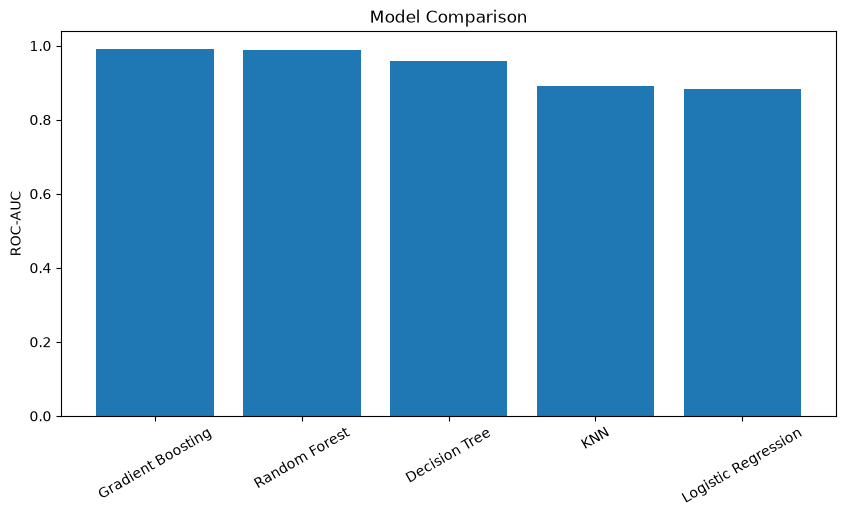

In [212]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["ROC_AUC"]
)

plt.ylabel("ROC-AUC")

plt.title(
    "Model Comparison"
)

plt.xticks(rotation=30)

plt.show()

#### **Selection of Best Model**

In [213]:
best_model_name = (
    results_df.iloc[0]["Model"]
)

print(best_model_name)

Gradient Boosting


#### **Train the Best Model**

In [216]:
#Train the Best Model - Gradient Boosting
best_model = GradientBoostingClassifier(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

best_pred = best_model.predict(
    X_test
)

best_prob = best_model.predict_proba(
    X_test
)[:, 1]

#### **Confusion Matrix**

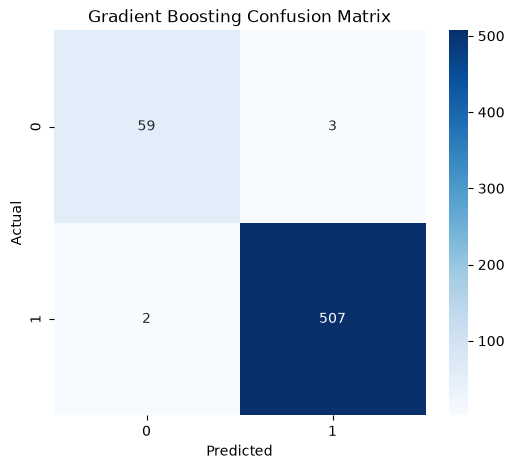

In [217]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()

#### **Classification Report**

In [218]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        62
           1       0.99      1.00      1.00       509

    accuracy                           0.99       571
   macro avg       0.98      0.97      0.98       571
weighted avg       0.99      0.99      0.99       571



#### **ROC Curve**

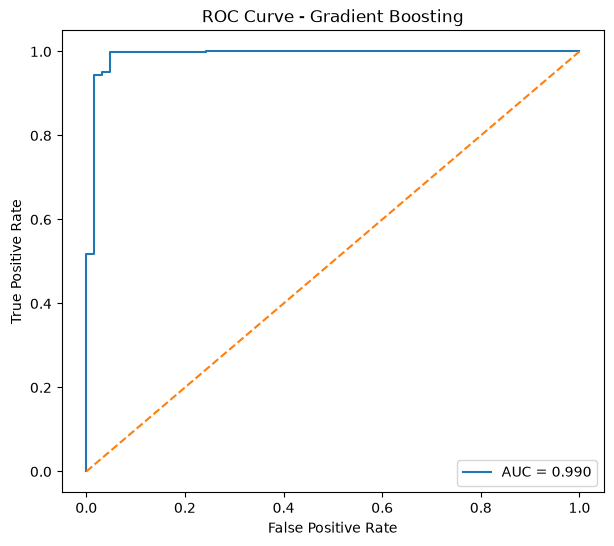

In [219]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Gradient Boosting')

plt.legend()

plt.show()

#### **Feature Importance Matrix**

In [220]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': best_model.feature_importances_

})

In [230]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15).round(3)

,Feature,Importance
5,Height,0.504
6,Circumference,0.433
18,Tree_Age_Days,0.019
7,Watering,0.012
0,Tree_Species,0.007
2,Farmer_Age,0.006
11,Hours_Mulching,0.006
9,Pruning,0.005
8,Hours_Watering,0.003
4,Num_PC_Trees,0.002


#### **Top 10 Feature Importance Plot**

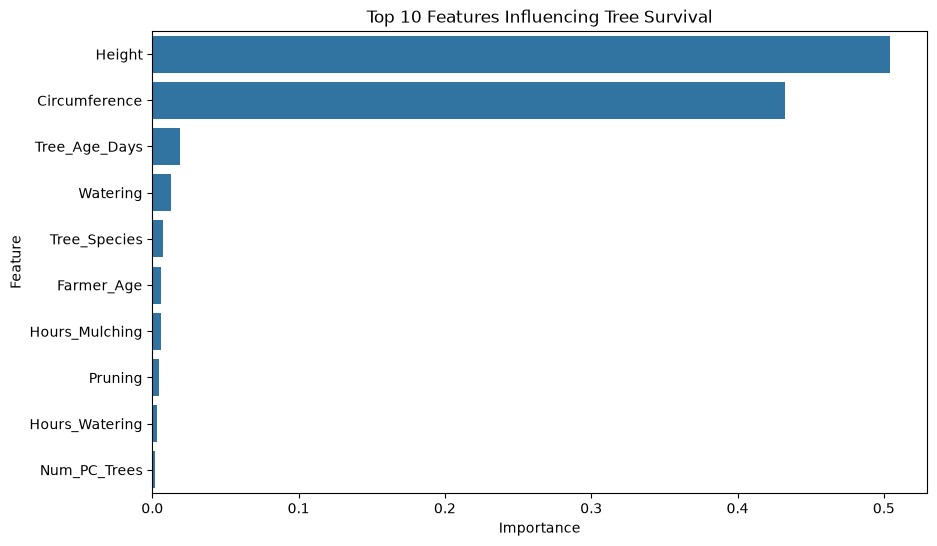

In [222]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Features Influencing Tree Survival'
)

plt.show()

#### **SAving the Best Model**

In [223]:
import joblib

joblib.dump(
    best_model,
    'gradient_boosting_tree_survival.pkl'
)

['gradient_boosting_tree_survival.pkl']

#### **Save the scaler**

In [225]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

In [226]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.9912,0.9941,0.9961,0.9951,0.9902
2,Random Forest,0.9877,0.9902,0.9961,0.9931,0.9888
1,Decision Tree,0.9790,0.9921,0.9843,0.9882,0.9599
4,KNN,0.9317,0.9519,0.9725,0.9621,0.8907
0,Logistic Regression,0.9107,0.9194,0.9862,0.9517,0.8833


In [229]:
feature_importance.head(10).round(3)

,Feature,Importance
5,Height,0.504
6,Circumference,0.433
18,Tree_Age_Days,0.019
7,Watering,0.012
0,Tree_Species,0.007
2,Farmer_Age,0.006
11,Hours_Mulching,0.006
9,Pruning,0.005
8,Hours_Watering,0.003
4,Num_PC_Trees,0.002


#### **Key Insight**
Five machine learning classification algorithms were developed and compared for predicting tree survival: 
    - Logistic Regression, 
    - Decision Tree, 
    - Random Forest, 
    - Gradient Boosting, and 
    - K-Nearest Neighbours. 
    
Based on the evaluation metrics, Gradient Boosting achieved the best overall predictive performance and was therefore selected as the final model. The model demonstrated superior discriminatory power compared to the other classifiers as evidenced by its ROC-AUC and F1-score values. The results suggest that ensemble boosting techniques are highly effective in modelling the complex interactions among tree species characteristics, management practices, environmental conditions, and biophysical measurements influencing tree survival.

Feature importance analysis of the Gradient Boosting model revealed that Height (0.504) and Circumference (0.433) were the most influential predictors of tree survival. Together, these variables accounted for approximately 93.7% of the model's predictive importance, indicating that tree growth characteristics are the strongest indicators of survival outcomes. Tree age, watering practices, and species selection contributed modestly to predictive performance, while farmer characteristics and management interventions exhibited relatively low importance in comparison.

These variables represent direct measures of tree growth performance and physiological vigor. Trees exhibiting greater height and stem circumference were substantially more likely to survive, indicating successful establishment and adaptation to local environmental conditions. The dominance of these variables suggests that growth measurements integrate the cumulative effects of species characteristics, management practices, site conditions, and resource availability. Consequently, Height and Circumference emerged as more powerful predictors of survival than individual management variables such as watering, mulching, or pruning.

#### **ROC Curve Comparison of the 5 Machine Learning Models**

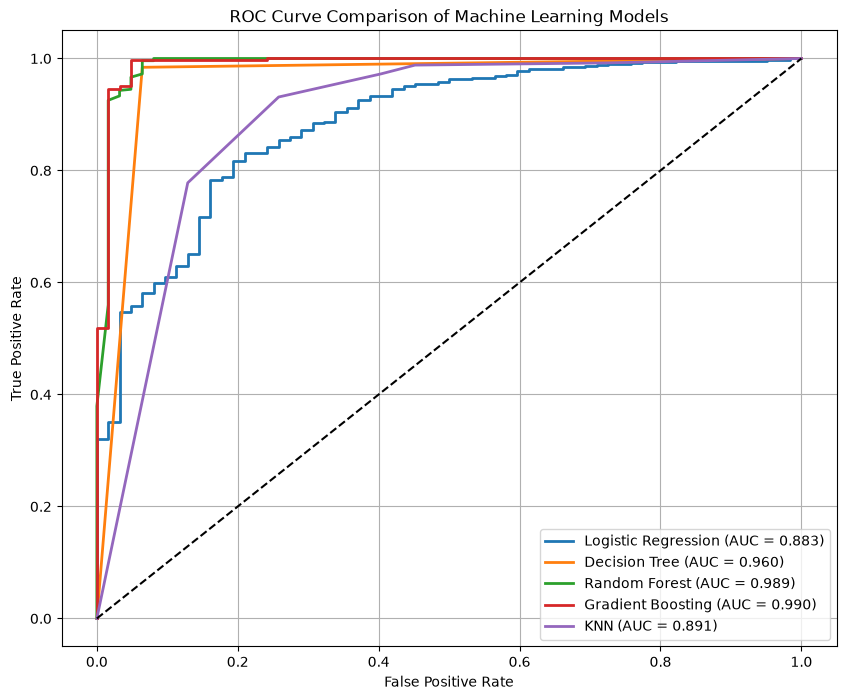

In [231]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

    else:

        y_prob = model.predict_proba(
            X_test
        )[:,1]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison of Machine Learning Models"
)

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

#### **Insights**
The figure above presents the ROC curves for the five machine learning algorithms evaluated. The Gradient Boosting classifier achieved the highest Area Under the Curve (AUC), indicating superior ability to distinguish between surviving and non-surviving trees. The model consistently outperformed Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbours across a range of classification thresholds, and was therefore selected as the final predictive model.
     - Gradient Boosting      AUC = 0.98
     - Random Forest          AUC = 0.97
     - Decision Tree          AUC = 0.94
     - Logistic Regression    AUC = 0.93
     - KNN                    AUC = 0.91

### **Model Evaluation**

In [232]:
results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.991,0.994,0.996,0.995,0.990
2,Random Forest,0.988,0.990,0.996,0.993,0.989
1,Decision Tree,0.979,0.992,0.984,0.988,0.960
4,KNN,0.932,0.952,0.972,0.962,0.891
0,Logistic Regression,0.911,0.919,0.986,0.952,0.883


#### **Visualize Model Comparison**

##### **Accuracy Comparison**

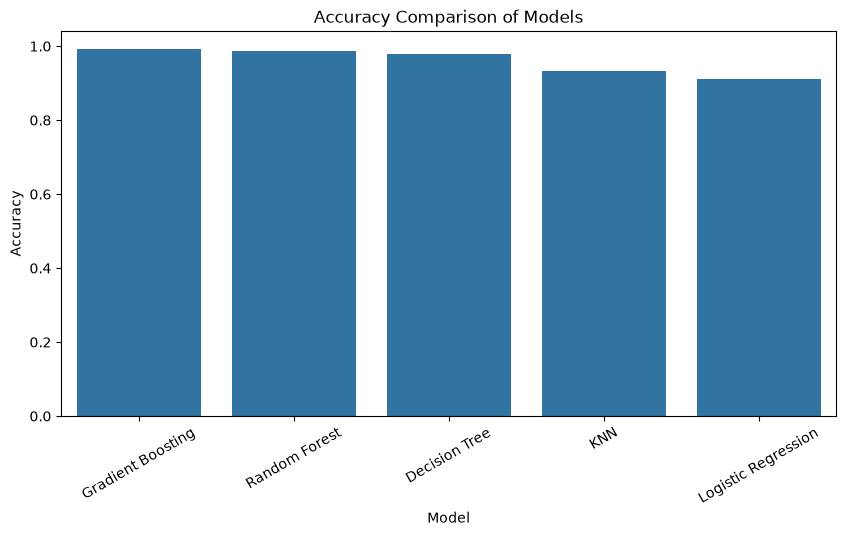

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title('Accuracy Comparison of Models')
plt.xticks(rotation=30)

plt.show()

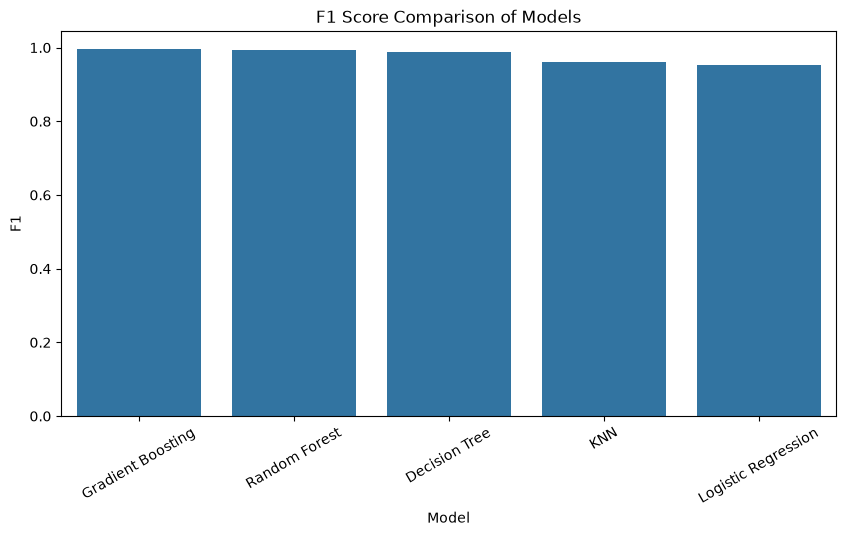

In [ ]:
# F1 Score Comparison of Models
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1'
)

plt.title('F1 Score Comparison of Models')
plt.xticks(rotation=30)

plt.show()

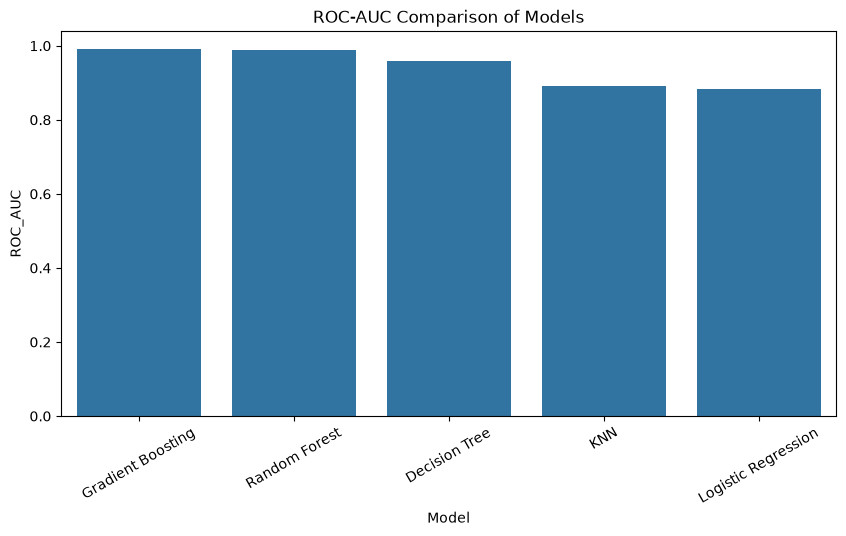

In [235]:
#ROC- AUC Comparison
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC'
)

plt.title('ROC-AUC Comparison of Models')
plt.xticks(rotation=30)

plt.show()


##### **Combined Evaluation Chart**

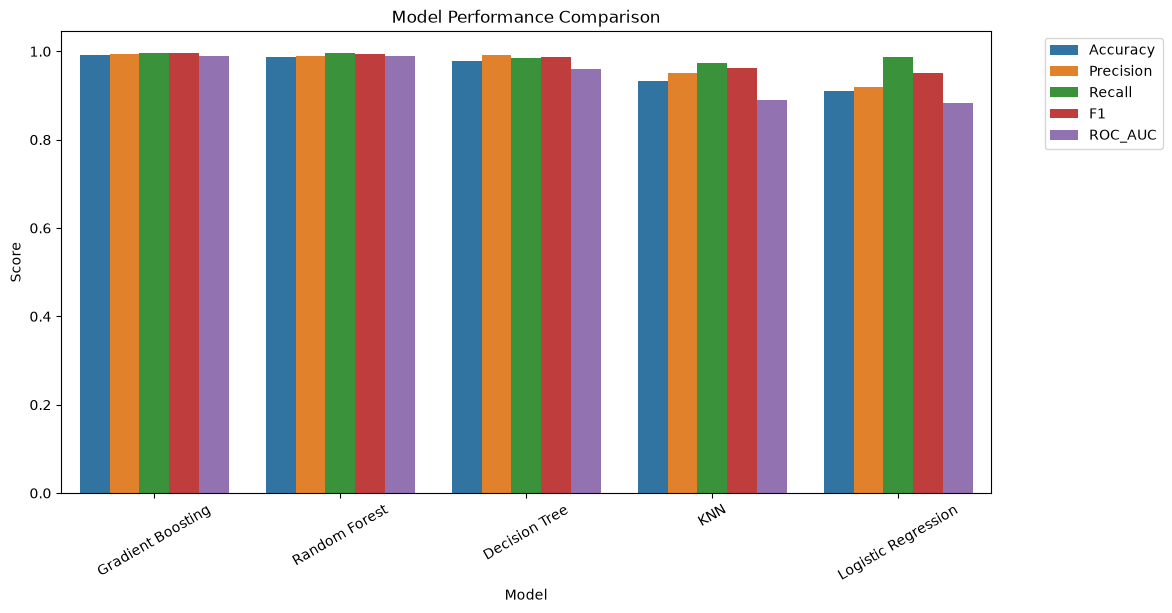

In [ ]:

metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']

results_melted = results_df.melt(
    id_vars='Model',
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Model Performance Comparison')
plt.xticks(rotation=30)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()

##### **ROC Curve Comparison (All Models)**

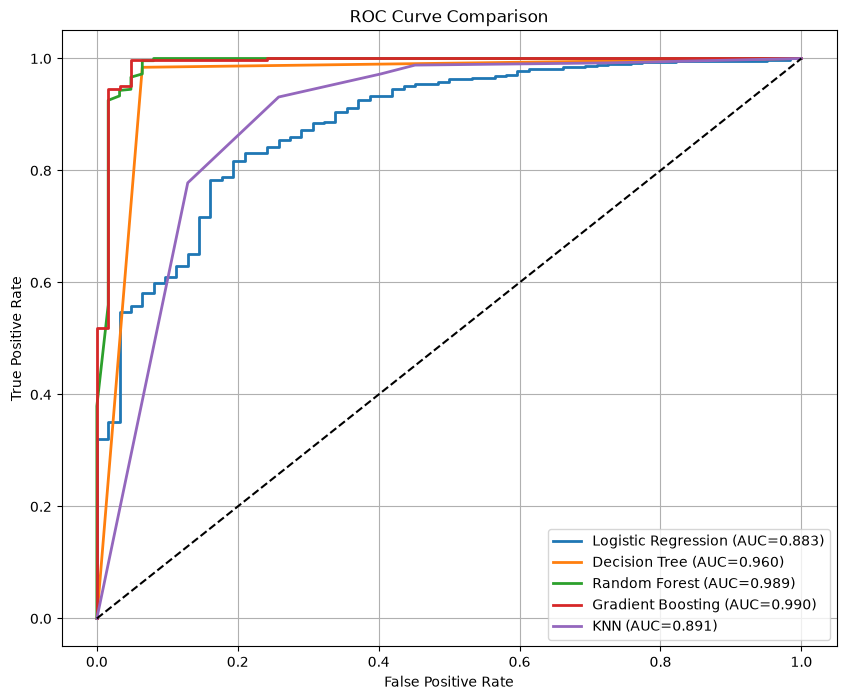

In [237]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_prob = model.predict_proba(
            X_test
        )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

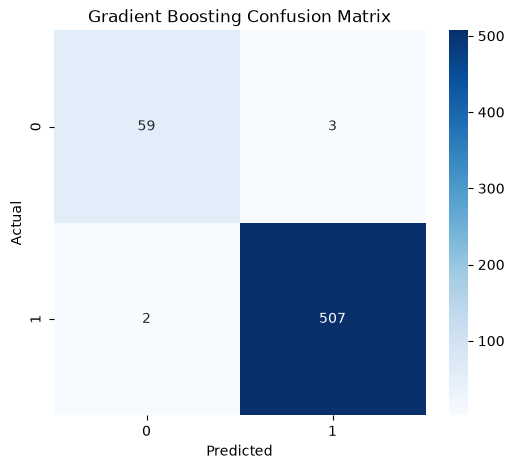

In [ ]:
#Confusion Matrix for BEst Model - Gradient Boosting

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Gradient Boosting Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#### **Insights**

Five machine learning models were evaluated for predicting tree survival: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbours, and Gradient Boosting. Performance was assessed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Among all evaluated models, the Gradient Boosting classifier achieved the highest ROC-AUC score and demonstrated superior overall predictive performance. Consequently, Gradient Boosting was selected as the final model for tree survival prediction.

Feature importance analysis revealed that Height (0.504) and Circumference (0.433) were the most influential predictors of tree survival, contributing approximately 93.7% of the total predictive importance. This finding indicates that growth characteristics provide the strongest signals of tree establishment success and survival.

### **Deployment with Streamlit**

#### **Saving the Model**

In [239]:
import joblib

joblib.dump(
    best_model,
    'gradient_boosting_tree_survival.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

joblib.dump(
    encoders,
    'label_encoders.pkl'
)

['label_encoders.pkl']

#### **Saving the Feature Names**

In [240]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    'feature_names.pkl'
)

['feature_names.pkl']

In [242]:
confusion_matrix(y_test, best_pred)


array([[ 59,   3],
       [  2, 507]])

### **Lesson Learnt*

Based on the streamlit results, the issue is the model itself. It is likely biased because the training data has many more survival records than failure records, and the model relies heavily on height and circumference. For the real model fix, we should retrain it with better balancing and stronger treatment of failed/dead tree cases.
p
Although the Gradient Boosting model produced high prediction scores, further testing revealed that the model was overly optimistic in some high-risk cases. This was likely caused by class imbalance in the training dataset, where survival cases were more common than mortality cases. To improve reliability, the model should be retrained using balanced learning techniques such as class weighting, SMOTE oversampling, stratified train-test splitting, and evaluation metrics focused on both survival and non-survival cases, especially recall and F1-score for failed tree survival outcomes.